# PUNTO 1
1.	Los bancos comerciales tradicionales no solían basarse en modelos estadísticos para decidir si debían emitirse préstamos personales, aunque esto está cambiando rápidamente en la actualidad. Usted es un analista que trabaja en un banco comercial moderno y le han solicitado construir modelos para calificar a un cliente en torno al riesgo posible de impago. Va a encontrar un conjunto de datos llamado modern_bank.csv donde encuentra diferentes variables que describen a los prestatarios y al préstamo. Para este conjunto de datos

    a.	Identifique una variable estrechamente relacionada con la calificación de riesgo del cliente y a partir de esta construya un modelo de regresión logística que permita determinar dicha probabilidad.

    b.	Utilice todas las variables y construya un modelo de regresión logística multivariada que permita predecir la calificación de riesgo del cliente.

    c.	Utilice todas las variables necesarias y construya un modelo de máquina de soporte vectorial que permita predecir la probabilidad de riesgo del cliente.

    d.	Implemente un modelo de redes neuronales tipo perceptrón multicapa que le permita obtener la probabilidad de riesgo del cliente.

    e.	¿cuál modelo genera un mejor desempeño? Explique.


In [102]:
#Manejo de advertencias
import warnings
warnings.filterwarnings('ignore')

In [103]:
#IMPORTAR LIBRERÍAS
#Tratamiento de datos
import pandas as pd
import numpy as np

#Gráficos
import matplotlib.pyplot as plt
import seaborn as sb

#Preparación de datos
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn import set_config

#Modelado
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

#Evaluación
from sklearn.metrics import accuracy_score, confusion_matrix

Identificación de Variables del Conjunto de Datos
Este conjunto de datos contiene información relevante sobre solicitudes de préstamos y características de los solicitantes. A continuación, se presenta una breve descripción de cada variable:

- person_age: La edad del solicitante del préstamo.

- person_income: Los ingresos anuales del solicitante.

- person_home_ownership: Indica si el solicitante es propietario de su vivienda (por ejemplo, 'RENT', 'OWN', 'MORTGAGE').

- person_emp_length: La duración del empleo del solicitante en años.

- loan_intent: El propósito o la intención detrás del préstamo solicitado (por ejemplo, 'EDUCATION', 'MEDICAL', 'PERSONAL').

- loan_grade: La calificación de riesgo del préstamo asignada por la entidad crediticia (por ejemplo, 'A', 'B', 'C').

- loan_amnt: El monto del préstamo solicitado.

- loan_int_rate: La tasa de interés aplicada al préstamo.

- loan_status: El estado final del préstamo, donde un valor puede indicar si fue pagado o si entró en incumplimiento (variable objetivo).

- loan_percent_income: El porcentaje de los ingresos del solicitante que representa el monto del préstamo.

- cb_person_default_on_file: Indica si el solicitante ha tenido un incumplimiento en su historial crediticio ('Y'/'N').

- cb_person_cred_hist_length: La antigüedad del historial crediticio del solicitante en años.

In [104]:
#IMPORTAR DATOS
datos = pd.read_csv('modern_bank.csv' , sep=';')
datos

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,21,30000,MORTGAGE,5.0,VENTURE,B,6400,NaN,0,0.21,N,3
1996,21,30000,RENT,3.0,MEDICAL,B,14000,10.65,1,0.47,N,2
1997,24,30000,RENT,2.0,DEBTCONSOLIDATION,A,14000,7.90,1,0.47,N,2
1998,24,30000,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3075,NaN,0,0.10,N,4


In [105]:
datos.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1995,21,30000,MORTGAGE,5.0,VENTURE,B,6400,NaN,0,0.21,N,3
1996,21,30000,RENT,3.0,MEDICAL,B,14000,10.65,1,0.47,N,2
1997,24,30000,RENT,2.0,DEBTCONSOLIDATION,A,14000,7.90,1,0.47,N,2
1998,24,30000,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3075,NaN,0,0.10,N,4
1999,22,30000,RENT,6.0,VENTURE,A,14000,6.99,1,0.47,N,4


In [106]:
#Identificación de datos faltantes
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  2000 non-null   int64  
 1   person_income               2000 non-null   int64  
 2   person_home_ownership       2000 non-null   object 
 3   person_emp_length           1917 non-null   float64
 4   loan_intent                 2000 non-null   object 
 5   loan_grade                  2000 non-null   object 
 6   loan_amnt                   2000 non-null   int64  
 7   loan_int_rate               1817 non-null   float64
 8   loan_status                 2000 non-null   int64  
 9   loan_percent_income         2000 non-null   float64
 10  cb_person_default_on_file   2000 non-null   object 
 11  cb_person_cred_hist_length  2000 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 187.6+ KB


In [107]:
#Completitud de person_emp_length y loan_int_rate
mediaPersonEmpLength = datos['person_emp_length'].mean()
mediaLoanIntRate = datos['loan_int_rate'].mean()

datos['person_emp_length'].fillna(mediaPersonEmpLength, inplace = True)
datos['loan_int_rate'].fillna(mediaLoanIntRate, inplace = True)
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  2000 non-null   int64  
 1   person_income               2000 non-null   int64  
 2   person_home_ownership       2000 non-null   object 
 3   person_emp_length           2000 non-null   float64
 4   loan_intent                 2000 non-null   object 
 5   loan_grade                  2000 non-null   object 
 6   loan_amnt                   2000 non-null   int64  
 7   loan_int_rate               2000 non-null   float64
 8   loan_status                 2000 non-null   int64  
 9   loan_percent_income         2000 non-null   float64
 10  cb_person_default_on_file   2000 non-null   object 
 11  cb_person_cred_hist_length  2000 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 187.6+ KB


In [108]:
#Identificación de estadísticas descriptivas - variables numéricas
datos.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,23.787500,60980.08800,3.860720,12192.325000,11.783126,0.416500,0.221265,2.99450
std,5.161363,50529.70276,4.715297,9265.804568,3.063800,0.493102,0.147110,0.81474
min,20.000000,9600.00000,0.000000,500.000000,5.420000,0.000000,0.010000,2.00000
25%,22.000000,26612.50000,1.000000,2000.000000,9.910000,0.000000,0.087500,2.00000
50%,24.000000,47276.00000,3.000000,13000.000000,11.783126,0.000000,0.210000,3.00000
75%,25.000000,75000.00000,6.000000,20000.000000,13.870000,1.000000,0.330000,4.00000
max,144.000000,500000.00000,123.000000,35000.000000,21.270000,1.000000,0.830000,4.00000


In [109]:
#Identificación de estadísticas descriptivas - variables categóricas
datos.describe(include = 'object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,2000,2000,2000,2000
unique,4,6,7,2
top,RENT,EDUCATION,B,N
freq,1383,446,687,1575


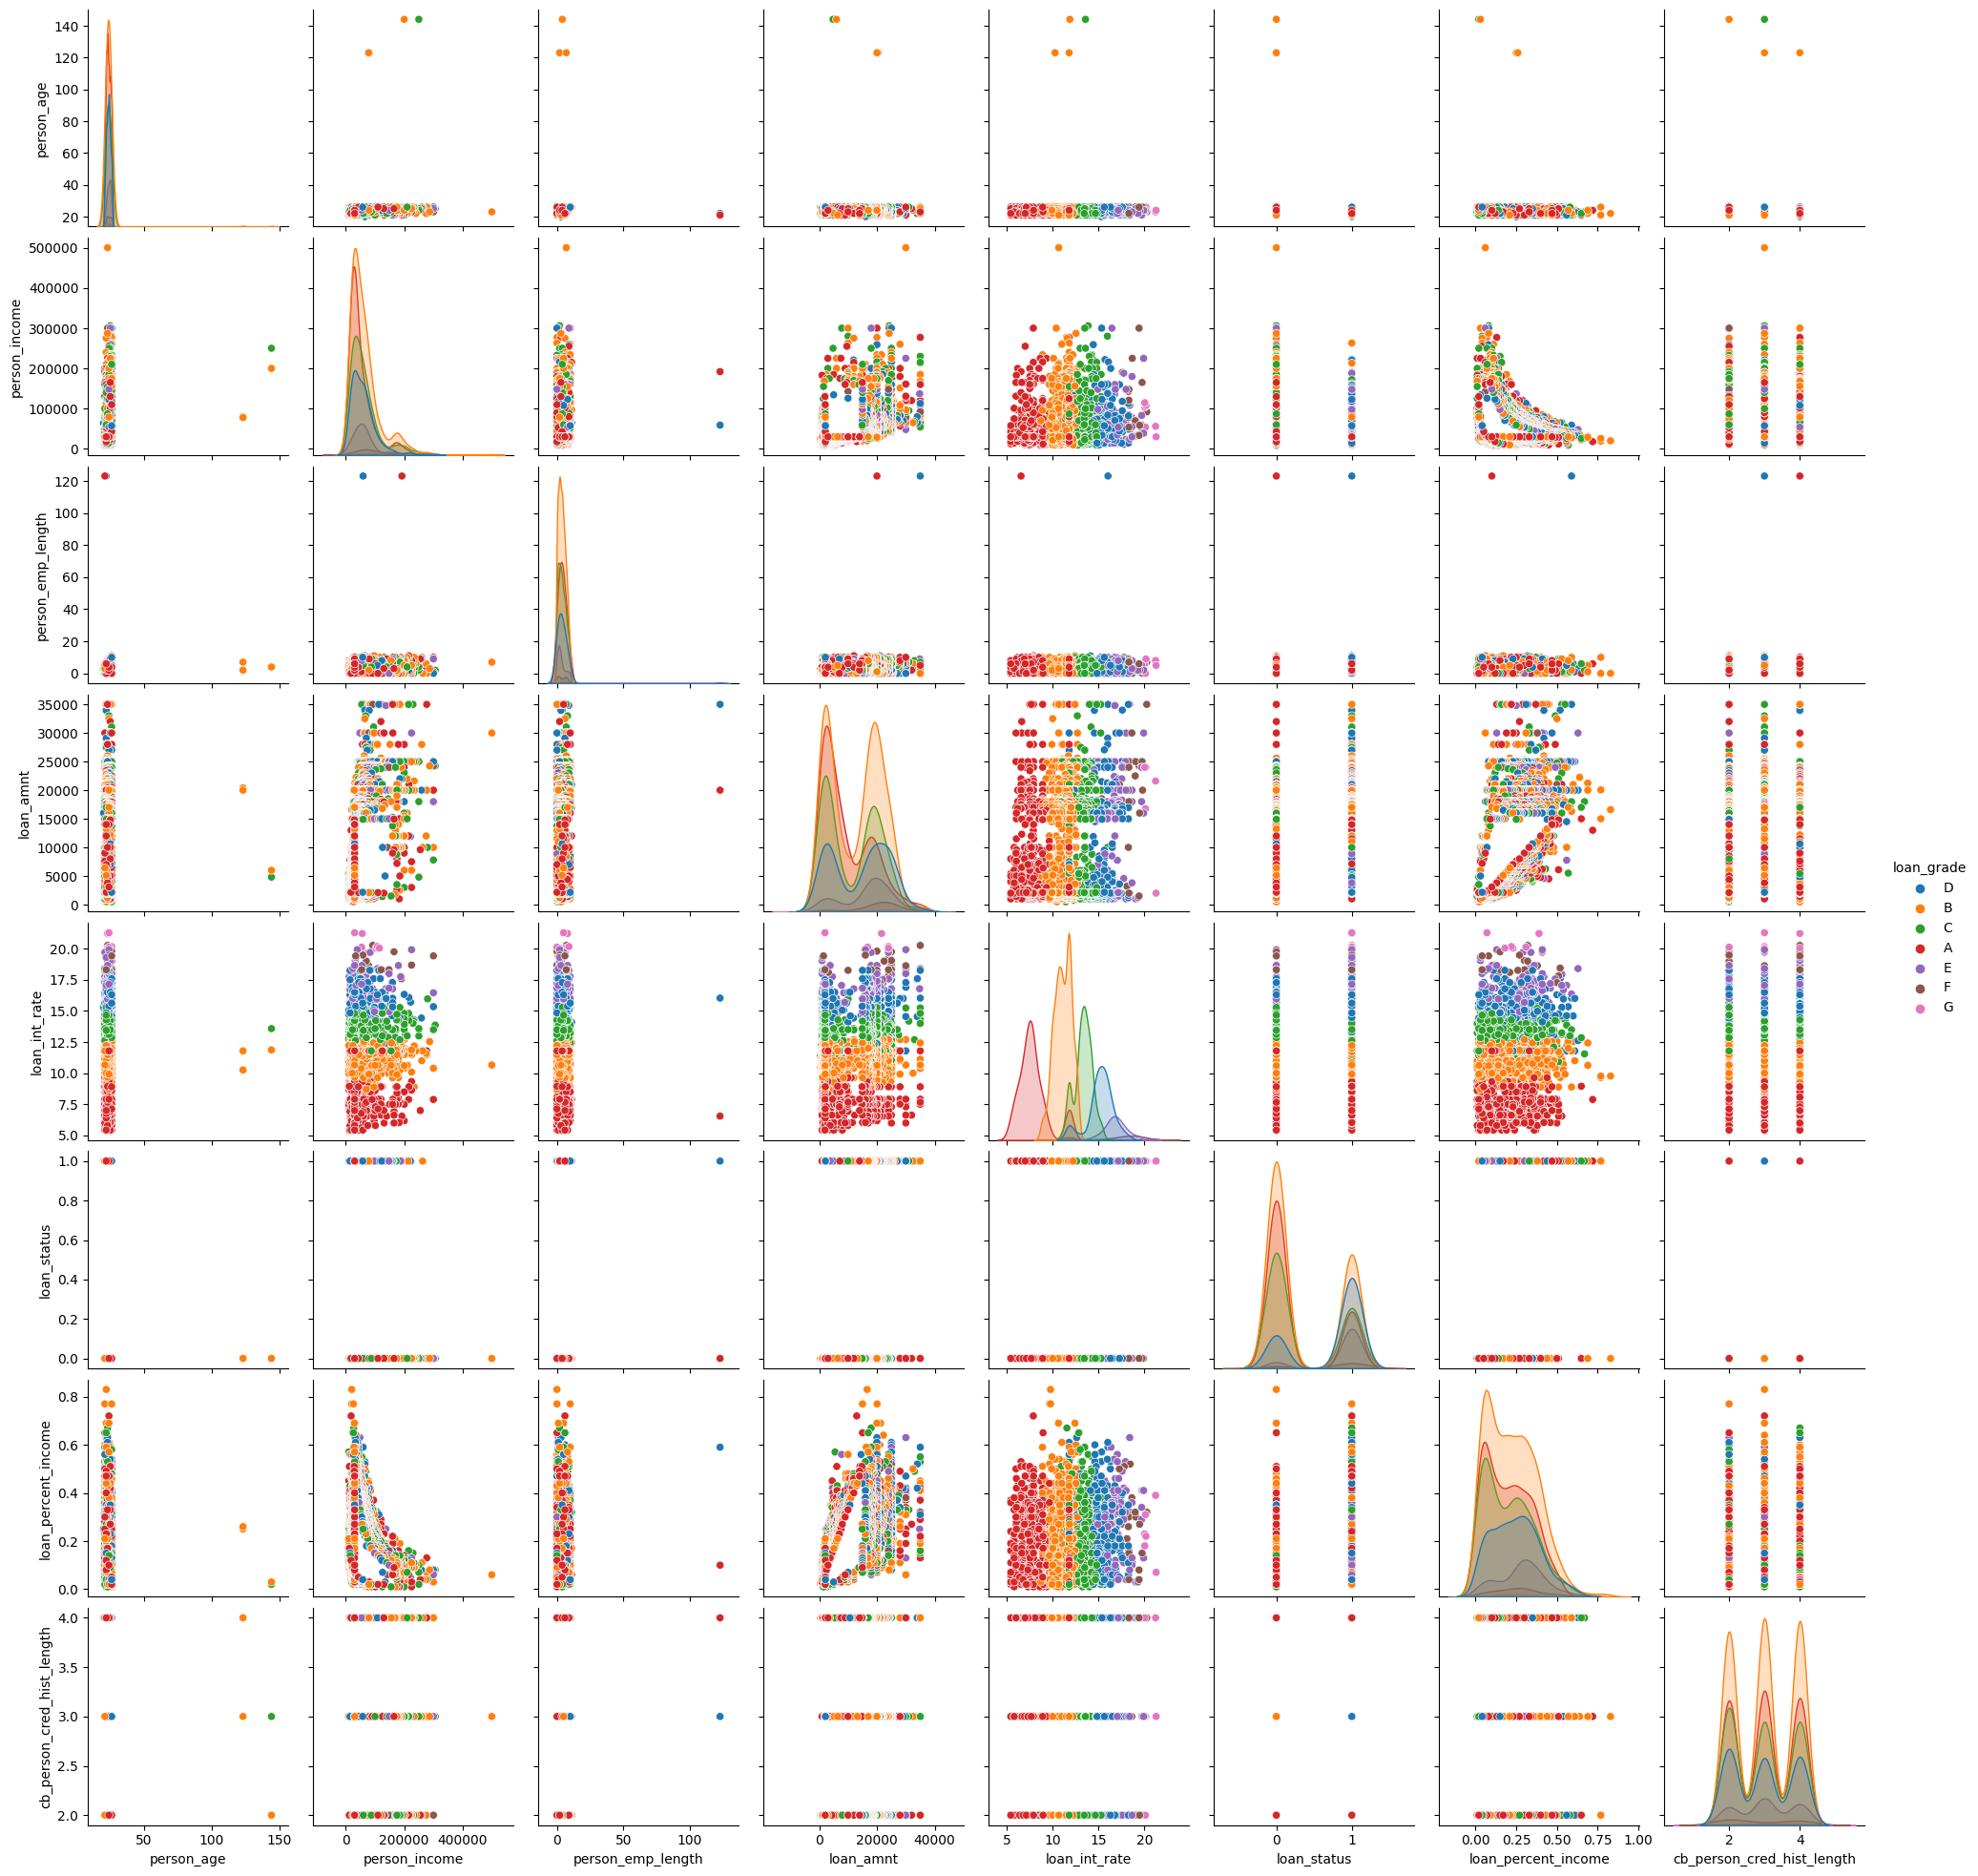

In [110]:
#Identificación gráfica
sb.pairplot(data = datos, hue = 'loan_grade', kind = 'scatter')
plt.show()

In [111]:
#Gráficamente se identifica que la variable loan_int_rate es capaz de separar la variable clasificadora

## Transformación de variables

In [112]:
#TRANSFORMACIÓN DE VARIABLES
numCols = datos.select_dtypes(include = ['float64', 'int64']).columns.to_list()
matCols = datos[['person_home_ownership', 'cb_person_default_on_file']].columns.to_list()
ordCols = datos[['loan_intent', 'loan_grade']].columns.to_list()

In [113]:
numTransformer = Pipeline(steps = [('scaler', MinMaxScaler())])
matTransformer = Pipeline(steps = [('onehot', OneHotEncoder(handle_unknown = 'ignore'))])
ordTransformer = Pipeline(steps = [('ordinal', OrdinalEncoder(handle_unknown = 'error'))])

In [114]:
preprocesador = ColumnTransformer(transformers = [
    ('num', numTransformer, numCols),
    ('mat', matTransformer, matCols),
    ('ord', ordTransformer, ordCols)
], remainder = 'passthrough')

set_config(display = 'diagram')
preprocesador

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['person_age', 'person_income',
                                  'person_emp_length', 'loan_amnt',
                                  'loan_int_rate', 'loan_status',
                                  'loan_percent_income',
                                  'cb_person_cred_hist_length']),
                                ('mat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['person_home_ownership',
                                  'cb_person_default_on_file']),
                                ('ord',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder())]),
                                 ['loan_intent', 'loan_grade'])])

In [115]:
datosPre = preprocesador.fit_transform(datos)
datosPre

array([[0.01612903, 0.10073409, 1.        , ..., 1.        , 4.        ,
        3.        ],
       [0.00806452, 0.        , 0.04065041, ..., 0.        , 1.        ,
        1.        ],
       [0.04032258, 0.        , 0.00813008, ..., 0.        , 3.        ,
        2.        ],
       ...,
       [0.03225806, 0.04159869, 0.01626016, ..., 0.        , 0.        ,
        0.        ],
       [0.03225806, 0.04159869, 0.03138797, ..., 0.        , 0.        ,
        0.        ],
       [0.01612903, 0.04159869, 0.04878049, ..., 0.        , 5.        ,
        0.        ]])

In [116]:
codCat = preprocesador.named_transformers_['mat']['onehot'].get_feature_names_out(matCols)
labels = np.concatenate([numCols, codCat, ordCols])
labels

array(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'cb_person_default_on_file_N',
       'cb_person_default_on_file_Y', 'loan_intent', 'loan_grade'],
      dtype=object)

In [117]:
datosPro = pd.DataFrame(datosPre, columns = labels)
datosPro.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,cb_person_default_on_file_N,cb_person_default_on_file_Y,loan_intent,loan_grade
0,0.016129,0.100734,1.000000,1.000000,0.668770,1.0,0.707317,0.5,0.0,0.0,0.0,1.0,0.0,1.0,4.0,3.0
1,0.008065,0.000000,0.040650,0.014493,0.360883,0.0,0.109756,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
2,0.040323,0.000000,0.008130,0.144928,0.470032,1.0,0.682927,0.5,1.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0
3,0.024194,0.113989,0.032520,1.000000,0.618927,1.0,0.634146,0.0,0.0,0.0,0.0,1.0,1.0,0.0,3.0,2.0
4,0.032258,0.091354,0.065041,1.000000,0.558360,1.0,0.658537,1.0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,2.0


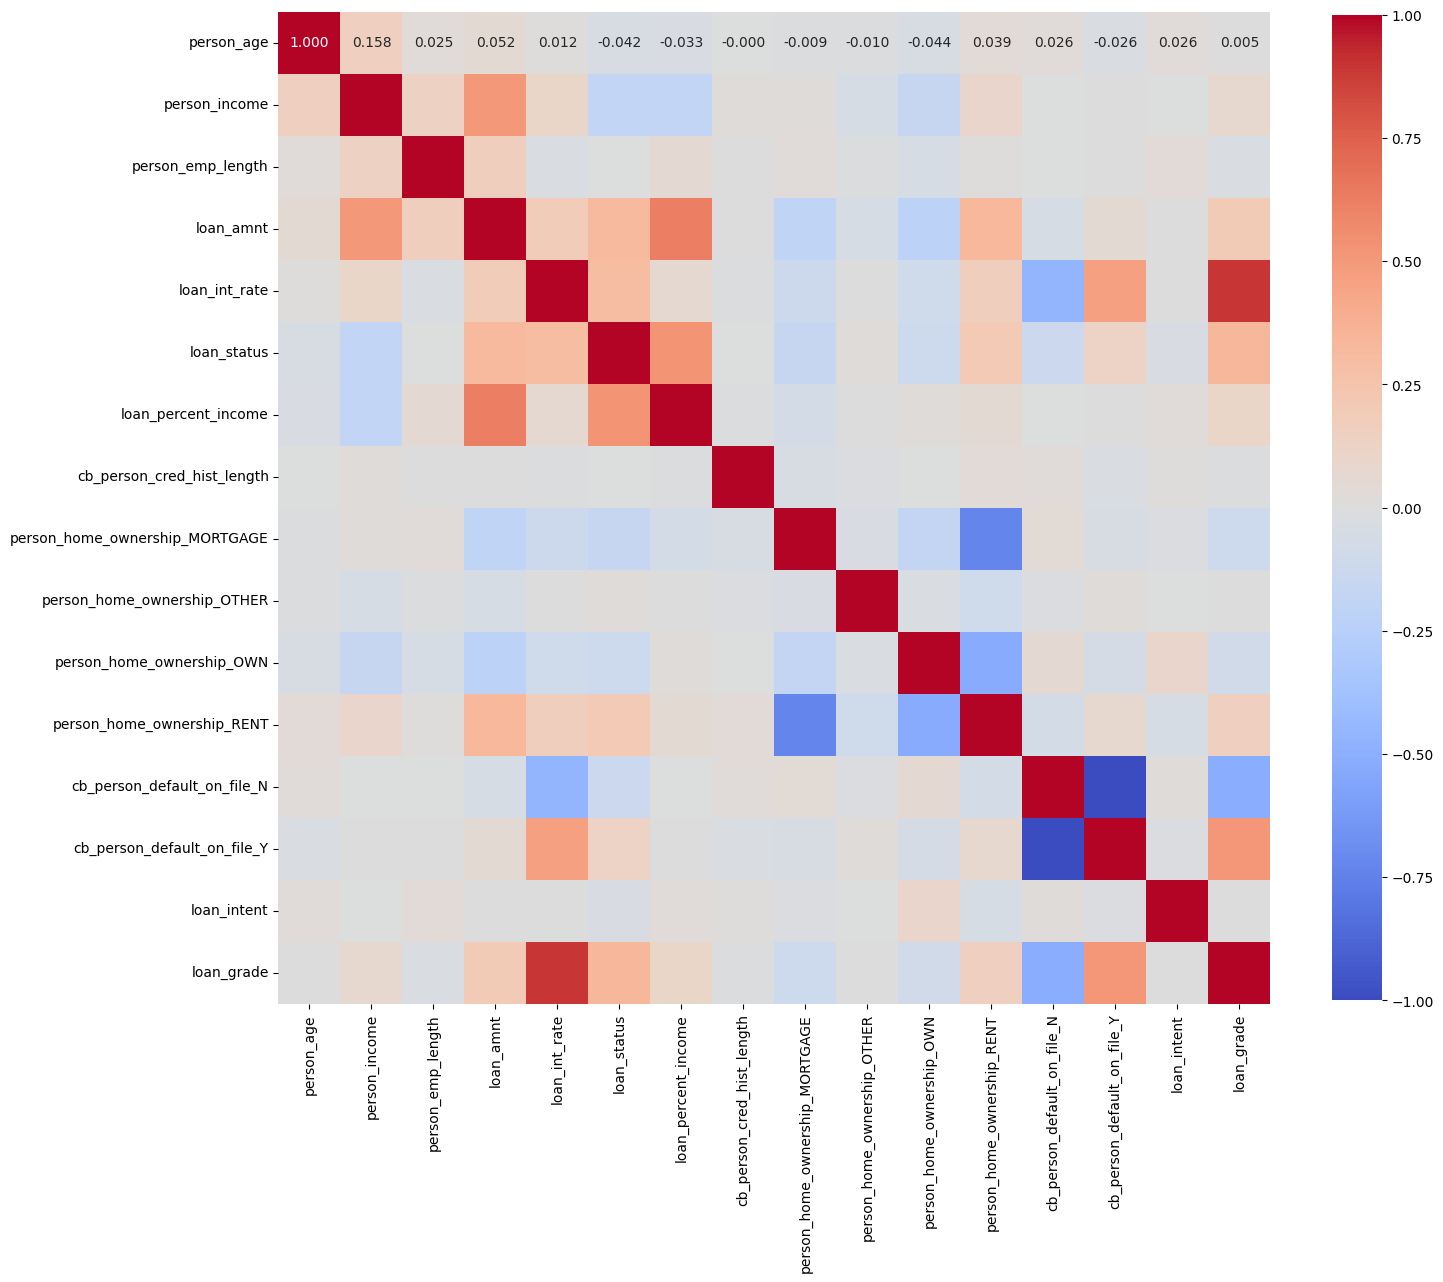

In [118]:
#Factor de correlación
plt.figure(figsize = (16, 16))
sb.heatmap(datosPro.corr(), annot = True, fmt = '.3f', cmap = 'coolwarm', square = True, cbar_kws = {'shrink': .8})
plt.show()

# PUNTO 1.A MODELO 1

In [119]:
#Punto 1.a
#La variable de mayor correlación con loan_grade es loan_int_rate
X1 = datosPro[['loan_int_rate']]
y1 = datosPro['loan_grade']

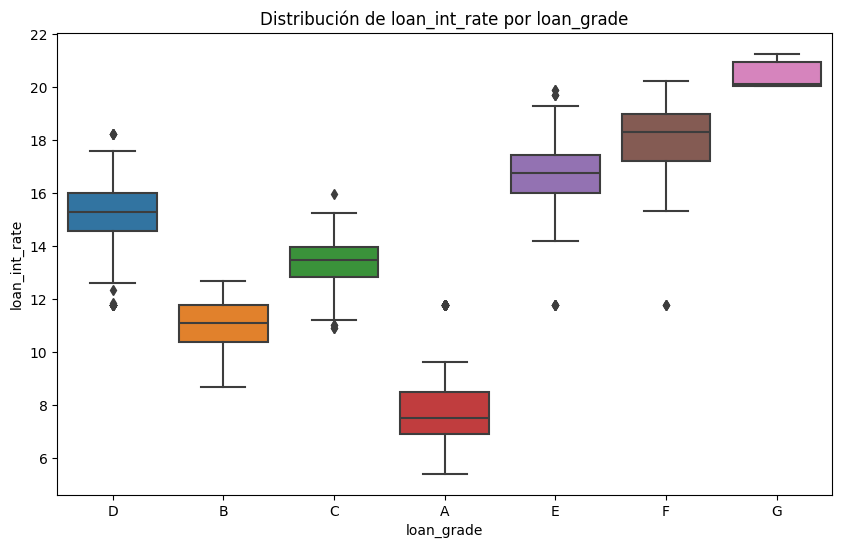

In [120]:
plt.figure(figsize=(10, 6))
sb.boxplot(x='loan_grade', y='loan_int_rate', data=datos)
plt.title('Distribución de loan_int_rate por loan_grade')
plt.xlabel('loan_grade')
plt.ylabel('loan_int_rate')
plt.show()

In [121]:
X1Entrenamiento, X1Prueba, y1Entrenamiento, y1Prueba = train_test_split(X1, y1, train_size = 0.7, random_state = 123)

In [122]:
#Ajuste del modelo
modelo1 = LogisticRegression(C = 1.0, random_state = 123)
modelo1.fit(X1Entrenamiento, y1Entrenamiento)

LogisticRegression(random_state=123)

In [123]:
modelo1.coef_

array([[-14.8163918 ],
       [ -5.7614312 ],
       [  1.43429353],
       [  5.99081947],
       [  6.56623468],
       [  4.67581278],
       [  1.91066253]])

In [124]:
modelo1.intercept_

array([ 6.73427821,  4.53212784,  0.93128263, -1.89830977, -3.37613424,
       -3.34900325, -3.57424142])

In [125]:
#fA = -41.13 X1 + 15.21
#fB = -17.38 X1 + 9.68
#fC = 1.49 X1 + 2.19
#fD = 11.31 X1 - 3.13
#fE = 16.51 X1 - 7.37
#fF = 16.81 X1 - 8.94
#fG = 12.39 X1 - 7.62

El accuracy de entenamiento es 0.7192857142857143


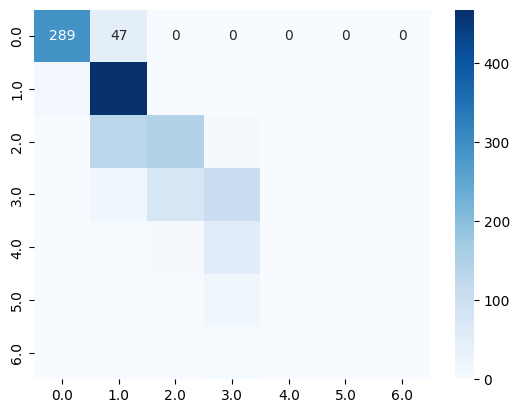

In [126]:
#Ajuste de entrenamiento
predModelo1Entrenamiento = modelo1.predict(X1Entrenamiento)
accuracyModelo1Entrenamiento = accuracy_score(y1Entrenamiento, predModelo1Entrenamiento)
matrizModelo1Entrenamiento = confusion_matrix(y1Entrenamiento, predModelo1Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo1Entrenamiento}')
sb.heatmap(matrizModelo1Entrenamiento, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = modelo1.classes_, yticklabels = modelo1.classes_)
plt.show()

El accuracy de prueba es 0.7066666666666667


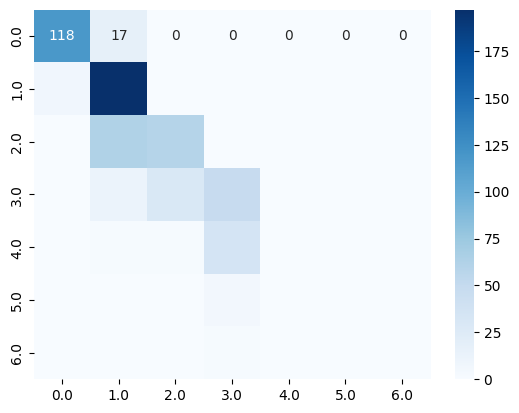

In [127]:
#Ajuste de prueba
predModelo1Prueba = modelo1.predict(X1Prueba)
accuracyModelo1Prueba = accuracy_score(y1Prueba, predModelo1Prueba)
matrizModelo1Prueba = confusion_matrix(y1Prueba, predModelo1Prueba)
print(f'El accuracy de prueba es {accuracyModelo1Prueba}')
sb.heatmap(matrizModelo1Prueba, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = modelo1.classes_, yticklabels = modelo1.classes_)
plt.show()

# PUNTO 1.B MODELO 2

In [128]:
#Punto 1.b
X2 = datosPro.drop('loan_grade', axis = 1)
y2 = datosPro['loan_grade']

In [129]:
X2Entrenamiento, X2Prueba, y2Entrenamiento, y2Prueba = train_test_split(X2, y2, train_size = 0.7, random_state = 123)

In [130]:
#Ajuste del modelo
modelo2 = LogisticRegression(C = 1.0, random_state = 123)
modelo2.fit(X2Entrenamiento, y2Entrenamiento)

LogisticRegression(random_state=123)

In [131]:
modelo2.coef_

array([[-2.92501193e-01, -3.33189518e-01,  3.24731940e-01,
        -5.69211410e-01, -1.34248359e+01, -8.54298698e-01,
         1.05139307e-01, -3.73552380e-02,  5.62848992e-01,
         7.37811076e-02,  4.89581776e-01,  1.96565308e-01,
         1.62636610e+00, -3.03588920e-01,  1.01157797e-02],
       [ 2.54801701e-01, -3.55535311e-01,  9.25149029e-03,
        -1.30160846e-01, -4.06321029e+00, -8.26261800e-01,
         3.07609085e-01, -3.52978249e-03,  2.15406541e-01,
         1.98531859e-01,  4.82179912e-02,  1.31119866e-01,
         2.08774243e+00, -1.49446617e+00,  4.91561323e-02],
       [ 5.50574557e-02,  4.57245855e-01, -1.59608989e-02,
        -8.64910193e-01,  1.12339279e+00, -1.00006763e+00,
         9.10825915e-01, -1.81858624e-01,  2.69535612e-02,
         4.03813007e-02, -1.33652189e-01,  3.30976829e-01,
        -6.37605618e-01,  9.02265121e-01, -4.38298005e-02],
       [-5.76221357e-02, -4.41465974e-01, -1.87037134e-01,
         1.19125519e-01,  4.84944117e+00,  7.04102547

In [132]:
modelo2.intercept_

array([ 5.1169862 ,  2.24850364,  1.96888612, -0.77457625, -3.10798229,
       -2.91792751, -2.5338899 ])

El accuracy de entenamiento es 0.7292857142857143


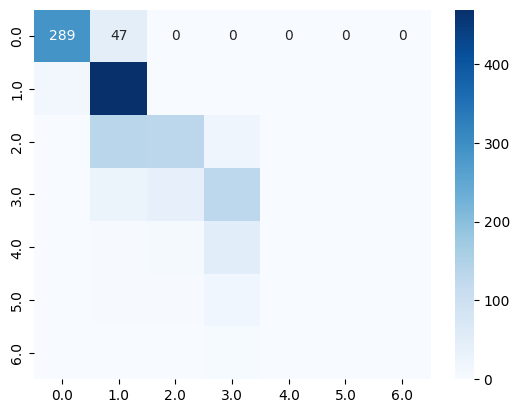

In [133]:
#Ajuste de entrenamiento
predModelo2Entrenamiento = modelo2.predict(X2Entrenamiento)
accuracyModelo2Entrenamiento = accuracy_score(y2Entrenamiento, predModelo2Entrenamiento)
matrizModelo2Entrenamiento = confusion_matrix(y2Entrenamiento, predModelo2Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo2Entrenamiento}')
sb.heatmap(matrizModelo2Entrenamiento, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = modelo2.classes_, yticklabels = modelo2.classes_)
plt.show()

El accuracy de prueba es 0.7166666666666667


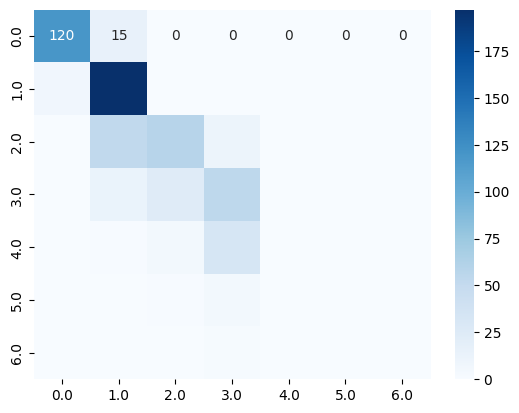

In [134]:
#Ajuste de prueba
predModelo2Prueba = modelo2.predict(X2Prueba)
accuracyModelo2Prueba = accuracy_score(y2Prueba, predModelo2Prueba)
matrizModelo2Prueba = confusion_matrix(y2Prueba, predModelo2Prueba)
print(f'El accuracy de prueba es {accuracyModelo2Prueba}')
sb.heatmap(matrizModelo2Prueba, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = modelo2.classes_, yticklabels = modelo2.classes_)
plt.show()

# PUNTO1.C MODELO 3

In [135]:
#Punto 1.c
#Variables elegidas: cb_person_default_on_file, person_home_ownership, loan_percent_income, loan_status, loan_int_rate, loan_amnt
X3 = datosPro[['loan_amnt', 'loan_int_rate', 'loan_status', 'person_home_ownership_MORTGAGE', 
               'person_home_ownership_OTHER', 'person_home_ownership_OWN','person_home_ownership_RENT', 
               'cb_person_default_on_file_N', 'cb_person_default_on_file_Y',]]
y3 = datosPro['loan_grade']

In [136]:
X3Entrenamiento, X3Prueba, y3Entrenamiento, y3Prueba = train_test_split(X3, y3, train_size = 0.7, random_state = 123)

In [137]:
#Ajuste del modelo
modelo3 = LogisticRegression(C = 1.0, random_state = 123)
modelo3.fit(X3Entrenamiento, y3Entrenamiento)

LogisticRegression(random_state=123)

El accuracy de entenamiento es 0.7214285714285714


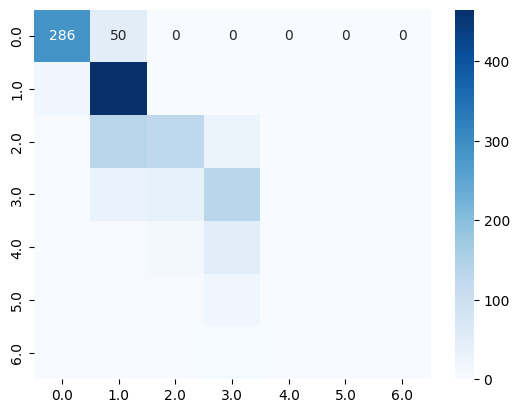

In [138]:
#Ajuste de entrenamiento
predModelo3Entrenamiento = modelo3.predict(X3Entrenamiento)
accuracyModelo3Entrenamiento = accuracy_score(y3Entrenamiento, predModelo3Entrenamiento)
matrizModelo3Entrenamiento = confusion_matrix(y3Entrenamiento, predModelo3Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo3Entrenamiento}')
sb.heatmap(matrizModelo3Entrenamiento, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = modelo3.classes_, yticklabels = modelo3.classes_)
plt.show()

El accuracy de prueba es 0.715


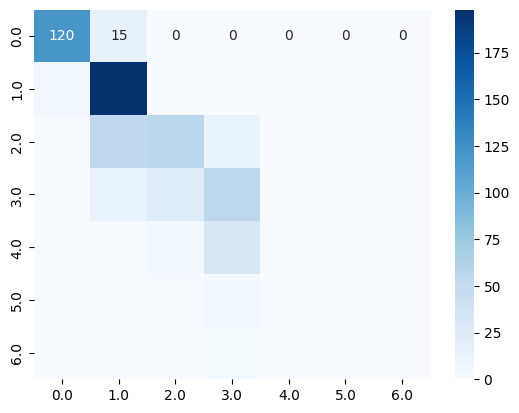

In [139]:
#Ajuste de prueba
predModelo3Prueba = modelo3.predict(X3Prueba)
accuracyModelo3Prueba = accuracy_score(y3Prueba, predModelo3Prueba)
matrizModelo3Prueba = confusion_matrix(y3Prueba, predModelo3Prueba)
print(f'El accuracy de prueba es {accuracyModelo3Prueba}')
sb.heatmap(matrizModelo3Prueba, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = modelo3.classes_, yticklabels = modelo3.classes_)
plt.show()

# PUNTO 1.D MODELO 4

In [140]:
#Punto 1.d
modelo4 = MLPClassifier(hidden_layer_sizes = (10, 20), random_state = 123)
modelo4.fit(X3Entrenamiento, y3Entrenamiento)

MLPClassifier(hidden_layer_sizes=(10, 20), random_state=123)

El accuracy de entenamiento es 0.8228571428571428


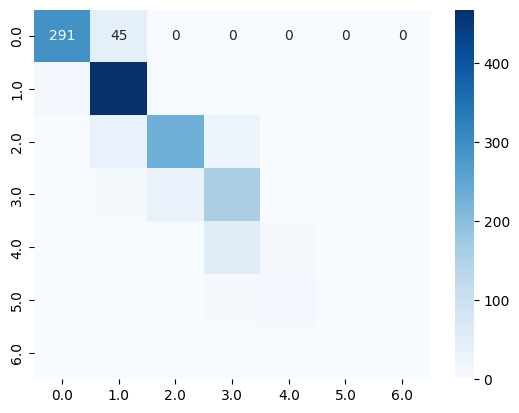

In [141]:
#Ajuste de entrenamiento
predModelo4Entrenamiento = modelo4.predict(X3Entrenamiento)
accuracyModelo4Entrenamiento = accuracy_score(y3Entrenamiento, predModelo4Entrenamiento)
matrizModelo4Entrenamiento = confusion_matrix(y3Entrenamiento, predModelo4Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo4Entrenamiento}')
sb.heatmap(matrizModelo4Entrenamiento, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = modelo4.classes_, yticklabels = modelo4.classes_)
plt.show()

El accuracy de prueba es 0.8083333333333333


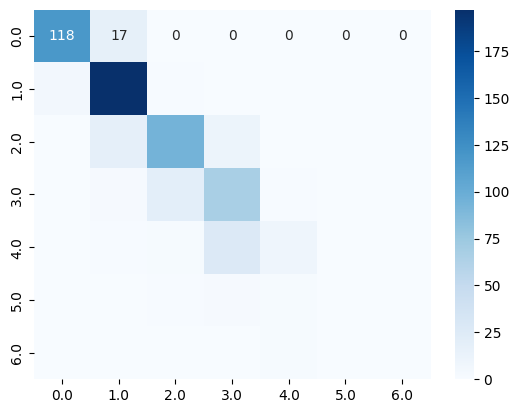

In [142]:
#Ajuste de prueba
predModelo4Prueba = modelo4.predict(X3Prueba)
accuracyModelo4Prueba = accuracy_score(y3Prueba, predModelo4Prueba)
matrizModelo4Prueba = confusion_matrix(y3Prueba, predModelo4Prueba)
print(f'El accuracy de prueba es {accuracyModelo4Prueba}')
sb.heatmap(matrizModelo4Prueba, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = modelo4.classes_, yticklabels = modelo4.classes_)
plt.show()

# Ranking de importancia de variables

In [143]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Usamos X2 (todas las variables preprocesadas) y y2 (loan_grade)
X = X2
y = y3

# Entrenamos el modelo
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X, y)

# Obtenemos la importancia de cada variable
importancias = modelo_rf.feature_importances_

# Creamos un DataFrame ordenado
ranking_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Mostramos las 15 variables más importantes
print(ranking_importancia.head(15))


                          Variable  Importancia
4                    loan_int_rate     0.480711
1                    person_income     0.079263
6              loan_percent_income     0.068769
3                        loan_amnt     0.068291
2                person_emp_length     0.052248
13     cb_person_default_on_file_Y     0.050705
12     cb_person_default_on_file_N     0.044900
14                     loan_intent     0.042865
0                       person_age     0.039519
5                      loan_status     0.027730
7       cb_person_cred_hist_length     0.026089
11      person_home_ownership_RENT     0.006748
8   person_home_ownership_MORTGAGE     0.006073
10       person_home_ownership_OWN     0.005553
9      person_home_ownership_OTHER     0.000537


# PUNTO 1.E DESEMPEÑOS
¿Comparación de desempeño entre modelos?

Comparación de Accuracy por modelo:

                                              Modelo  Accuracy Entrenamiento  \
0          Modelo 1 Regresión Logística (1 variable)                0.719286   
1  Modelo 2 Regresión Logística (todas las variab...                0.729286   
2                                       Modelo 3 SVM                0.721429   
3                          Modelo 4 Red Neuronal MLP                0.822857   
4            Modelo 5 Red Neuronal MLP (importantes)                0.821250   

   Accuracy Prueba  
0         0.706667  
1         0.716667  
2         0.715000  
3         0.808333  
4         0.807500  


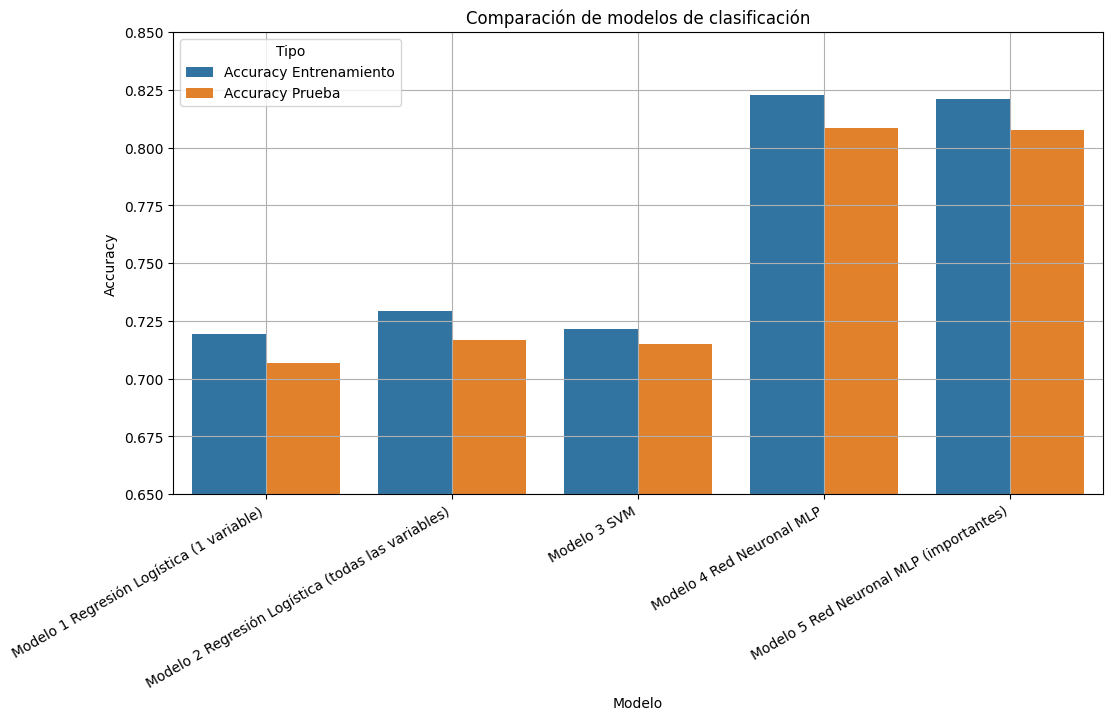

In [144]:
resultados = pd.DataFrame({
    'Modelo': [
        'Modelo 1 Regresión Logística (1 variable)',
        'Modelo 2 Regresión Logística (todas las variables)',
        'Modelo 3 SVM',
        'Modelo 4 Red Neuronal MLP',
        'Modelo 5 Red Neuronal MLP (importantes)'
    ],
    'Accuracy Entrenamiento': [
        accuracyModelo1Entrenamiento,
        accuracyModelo2Entrenamiento,
        accuracyModelo3Entrenamiento,
        accuracyModelo4Entrenamiento,
        accuracy5Entrenamiento
    ],
    'Accuracy Prueba': [
        accuracyModelo1Prueba,
        accuracyModelo2Prueba,
        accuracyModelo3Prueba,
        accuracyModelo4Prueba,
        accuracy5Prueba
    ]
})

# Mostrar la tabla
print("Comparación de Accuracy por modelo:\n")
print(resultados)

# Visualización opcional
plt.figure(figsize=(12, 6))
sb.barplot(data=resultados.melt(id_vars='Modelo', var_name='Tipo', value_name='Accuracy'),
           x='Modelo', y='Accuracy', hue='Tipo')
plt.title("Comparación de modelos de clasificación")
plt.xticks(rotation=30, ha='right')
plt.ylim(0.65, 0.85)
plt.grid(True)
plt.show()

# PUNTO 1.F ANEXO MODELO 5

- Generar un nuevo conjunto X5 teniendo en cuenta el ranking de las variables que mas explicando a loand grade

In [145]:
y5.head()

0    3.0
1    1.0
2    2.0
3    2.0
4    2.0
Name: loan_grade, dtype: float64

In [146]:
# Paso 1: Selección de variables más importantes
['loan_int_rate', 'person_income', 'loan_percent_income',
 'loan_amnt', 'person_emp_length', 'person_home_ownership_MORTGAGE',
 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 
 'cb_person_default_on_file_Y', 'cb_person_default_on_file_N']


['loan_int_rate',
 'person_income',
 'loan_percent_income',
 'loan_amnt',
 'person_emp_length',
 'person_home_ownership_MORTGAGE',
 'person_home_ownership_OTHER',
 'person_home_ownership_OWN',
 'person_home_ownership_RENT',
 'cb_person_default_on_file_Y',
 'cb_person_default_on_file_N']

Accuracy entrenamiento (X5): 0.8213
Accuracy prueba (X5): 0.8075


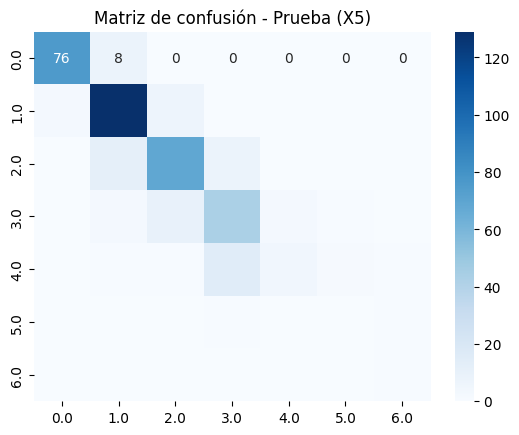

In [147]:
X5 = datosPro[['loan_int_rate', 'person_income', 'loan_percent_income','loan_amnt', 'person_emp_length', 
               'person_home_ownership_MORTGAGE','person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT',
               'cb_person_default_on_file_Y', 'cb_person_default_on_file_N']]
            
y5 = datosPro['loan_grade']

# Paso 2: Dividir los datos en conjuntos de entrenamiento y prueba
X5Entrenamiento, X5Prueba, y5Entrenamiento, y5Prueba = train_test_split(X5, y5, train_size = 0.8, random_state = 123)

# Paso 3: Crear y ajustar modelo MLP
from sklearn.neural_network import MLPClassifier

modelo5 = MLPClassifier(hidden_layer_sizes=(10, 20), random_state=123, max_iter=1000)
modelo5.fit(X5Entrenamiento, y5Entrenamiento)

# Paso 4: Evaluación en entrenamiento
pred5Entrenamiento = modelo5.predict(X5Entrenamiento)
accuracy5Entrenamiento = accuracy_score(y5Entrenamiento, pred5Entrenamiento)
print(f"Accuracy entrenamiento (X5): {accuracy5Entrenamiento:.4f}")

# Paso 5: Evaluación en prueba
pred5Prueba = modelo5.predict(X5Prueba)
accuracy5Prueba = accuracy_score(y5Prueba, pred5Prueba)
print(f"Accuracy prueba (X5): {accuracy5Prueba:.4f}")

# Paso 6: Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sb
import matplotlib.pyplot as plt

matriz5 = confusion_matrix(y5Prueba, pred5Prueba)
sb.heatmap(matriz5, annot=True, fmt='d', cmap='Blues', xticklabels=modelo5.classes_, yticklabels=modelo5.classes_)
plt.title("Matriz de confusión - Prueba (X5)")
plt.show()

# PUNTO 1.G APLICACION DEL MODELO

Generaremos una base de datos para clientes nuevos y asi poder aplicar el modelo MLP

## TRANSFORMACIÓN DE VARIABLES CORRECTAS

In [148]:
import pandas as pd
import numpy as np

np.random.seed(123)
n = 2000

clientes_simulados = pd.DataFrame({
    'person_age': np.random.randint(18, 70, n),
    'person_income': np.random.randint(20000, 100000, n),
    'person_home_ownership': np.random.choice(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], size=n),
    'person_emp_length': np.random.randint(0, 15, n),
    'loan_intent': np.random.choice(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION'], size=n),
    'loan_amnt': np.random.randint(2000, 20000, n),
    'loan_int_rate': np.round(np.random.uniform(0.05, 0.8, n), 3),
    'loan_status': np.random.choice([0, 1], size=n),
    'loan_percent_income': np.round(np.random.uniform(0.1, 0.5, n), 3),
    'cb_person_default_on_file': np.random.choice(['Y', 'N'], size=n),
    'cb_person_cred_hist_length': np.random.randint(1, 30, n)
    })

In [149]:
clientes_simulados.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,63,40500,RENT,3,PERSONAL,11294,0.692,1,0.478,Y,25
1,20,38386,RENT,1,HOMEIMPROVEMENT,17802,0.086,0,0.452,Y,20
2,46,66657,RENT,13,EDUCATION,16888,0.629,0,0.167,N,2
3,52,87280,RENT,4,HOMEIMPROVEMENT,14966,0.630,1,0.209,N,6
4,56,55303,OTHER,2,VENTURE,18207,0.103,0,0.184,Y,17


## Transformación de clientes nuevos

In [150]:
# Transformaciones como en el entrenamiento
numCols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
           'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']
matCols = ['person_home_ownership', 'cb_person_default_on_file']
ordCols = ['loan_intent']  # solo usamos loan_intent como ordinal

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Codificadores
numTransformer = Pipeline(steps=[('scaler', MinMaxScaler())])
matTransformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])
ordTransformer = Pipeline(steps=[('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])

# Preprocesador
preprocesador1 = ColumnTransformer(transformers=[
    ('num', numTransformer, numCols),
    ('mat', matTransformer, matCols),
    ('ord', ordTransformer, ordCols)
], remainder='passthrough')

set_config(display = 'diagram')
preprocesador1


ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['person_age', 'person_income',
                                  'person_emp_length', 'loan_amnt',
                                  'loan_int_rate', 'loan_status',
                                  'loan_percent_income',
                                  'cb_person_cred_hist_length']),
                                ('mat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['person_home_ownership',
                                  'cb_person_default_on_file']),
                                ('ord',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['loan_intent'])])

In [151]:
clientes_simulados_transf = preprocesador1.fit_transform(clientes_simulados)

In [152]:
codCat = preprocesador1.named_transformers_['mat']['onehot'].get_feature_names_out(matCols)
labels = np.concatenate([numCols, codCat, ordCols])
labels


array(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'cb_person_default_on_file_N',
       'cb_person_default_on_file_Y', 'loan_intent'], dtype=object)

In [153]:
clientes_simulados_transf = preprocesador1.fit_transform(datos)
clientes_simulados_transf


array([[0.01612903225806453, 0.10073409461663949, 1.0, ..., 1.0, 4.0,
        'D'],
       [0.008064516129032251, 0.0, 0.04065040650406505, ..., 0.0, 1.0,
        'B'],
       [0.04032258064516128, 0.0, 0.008130081300813009, ..., 0.0, 3.0,
        'C'],
       ...,
       [0.03225806451612903, 0.04159869494290376, 0.016260162601626018,
        ..., 0.0, 0.0, 'A'],
       [0.03225806451612903, 0.04159869494290376, 0.03138796646182425,
        ..., 0.0, 0.0, 'A'],
       [0.01612903225806453, 0.04159869494290376, 0.04878048780487805,
        ..., 0.0, 5.0, 'A']], dtype=object)

In [154]:
clientes_simulados_transf = pd.DataFrame(datosPre, columns = labels)
clientes_simulados_transf.head()

ValueError: Shape of passed values is (2000, 16), indices imply (2000, 15)

## Realización de predicciones

In [ ]:
# Seleccion de variables más importantes
columnas_X5 = X5.columns.tolist()

clientes_simulados_final = clientes_simulados_transf[columnas_X5]

In [ ]:
# Predicciones con el modelo entrenado
predicciones_simuladas = modelo5.predict(clientes_simulados_final)
clientes_simulados['loan_grade_pred'] = predicciones_simuladas

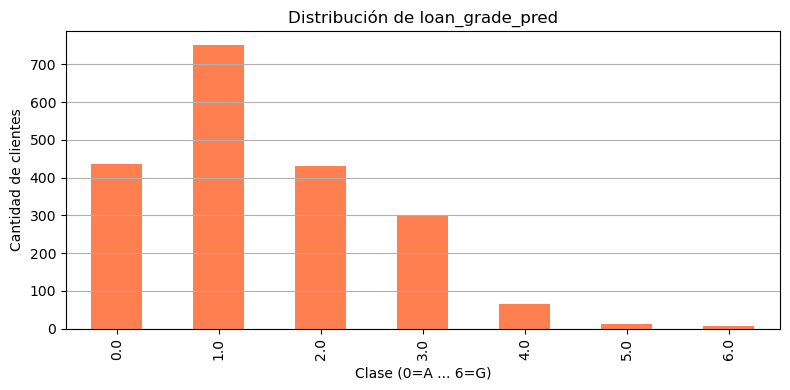

In [ ]:
# Visualización de las predicciones
clientes_simulados['loan_grade_pred'].value_counts().sort_index().plot(
    kind='bar',
    title='Distribución de loan_grade_pred',
    xlabel='Clase (0=A ... 6=G)',
    ylabel='Cantidad de clientes',
    figsize=(8, 4),
    color='coral'
)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

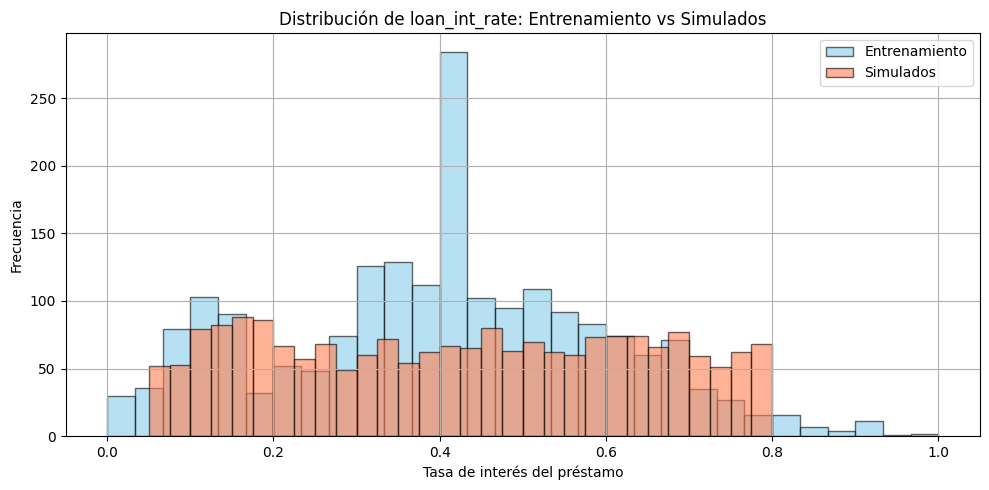

In [ ]:
plt.figure(figsize=(10, 5))

# Histograma del conjunto de entrenamiento
plt.hist(X5['loan_int_rate'], bins=30, alpha=0.6, label='Entrenamiento', color='skyblue', edgecolor='black')

# Histograma del conjunto de clientes simulados
plt.hist(clientes_simulados['loan_int_rate'], bins=30, alpha=0.6, label='Simulados', color='coral', edgecolor='black')

plt.title('Distribución de loan_int_rate: Entrenamiento vs Simulados')
plt.xlabel('Tasa de interés del préstamo')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusión 1

Conclusion del resultado en la apliación

Debemos tener en cuenta que cuando creamos los datos de los nuevos clientes, estos tenían una distribución muy diferente a los datos de entrenamiento inicial, por lo tanto siempre debemos tener en cuenta que si queremos hacer practicas en datos nuevos, estos deben tener distribuciones similares

In [ ]:
print("loan_int_rate (entrenamiento):")
print(X5['loan_int_rate'].describe())

print("\nloan_int_rate (nuevos clientes):")
print(clientes_simulados['loan_int_rate'].describe())

loan_int_rate (entrenamiento):
count    2000.000000
mean        0.401459
std         0.193300
min         0.000000
25%         0.283281
50%         0.401459
75%         0.533123
max         1.000000
Name: loan_int_rate, dtype: float64

loan_int_rate (nuevos clientes):
count    2000.000000
mean        0.174937
std         0.073154
min         0.050000
25%         0.111000
50%         0.174000
75%         0.238000
max         0.300000
Name: loan_int_rate, dtype: float64


## Normalización errones

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X5_esc = scaler.fit_transform(X5)
clientes_simulados_esc = scaler.transform(clientes_simulados[X5.columns])


KeyError: "['person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'cb_person_default_on_file_Y', 'cb_person_default_on_file_N'] not in index"

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Fit the LabelEncoder on the original y5 if not already done
le = LabelEncoder()
le.fit(y5)

pred_cod = modelo5.predict(clientes_simulados_esc)
clientes_simulados['loan_grade_pred_cod'] = pred_cod

# Convert pred_cod to integer type for inverse_transform
clientes_simulados['loan_grade_pred'] = le.inverse_transform(pred_cod.astype(int))


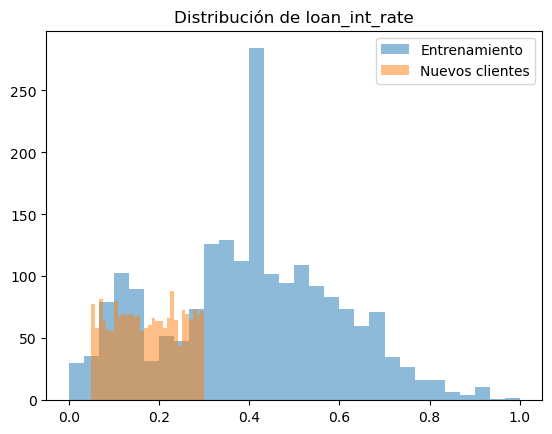

In [ ]:
import matplotlib.pyplot as plt

plt.hist(X5['loan_int_rate'], bins=30, alpha=0.5, label='Entrenamiento')
plt.hist(clientes_simulados['loan_int_rate'], bins=30, alpha=0.5, label='Nuevos clientes')
plt.legend()
plt.title("Distribución de loan_int_rate")
plt.show()


In [ ]:
# Primer intento que dio lugar a predicciones solo en clases 0 y 1
np.random.seed(123)  # reproducibilidad

n = 2000  # número de clientes simulados

clientes_simulados = pd.DataFrame({
    'loan_int_rate': np.round(np.random.uniform(0.05, 0.3, n), 3),  # tasas entre 5% y 30%
    'person_income': np.random.randint(20000, 100000, n),           # ingresos entre 20k y 100k
    'loan_percent_income': np.round(np.random.uniform(0.1, 0.5, n), 2),  # entre 10% y 50%
    'loan_amnt': np.random.randint(2000, 20000, n),                 # montos entre 2M y 20M
    'person_emp_length': np.random.randint(0, 15, n),               # años de empleo entre 0 y 15
    'person_home_ownership_MORTGAGE': np.random.choice([0, 1], size=n, p=[0.5, 0.5]),
    'person_home_ownership_OTHER': np.random.choice([0, 1], size=n, p=[0.5, 0.5]),
    'person_home_ownership_OWN': np.random.choice([0, 1], size=n, p=[0.5, 0.5]),
    'person_home_ownership_RENT': np.random.choice([0, 1], size=n, p=[0.5, 0.5]),
    'cb_person_default_on_file_Y': np.random.choice([0, 1], size=n, p=[0.85, 0.15]),
    'cb_person_default_on_file_N': 1 - np.random.choice([0, 1], size=n, p=[0.85, 0.15])
})


## Conclusión 2

❌ ¿Qué salió mal con este intento?

Distribuciones no representativas:
1. Las variables numéricas como loan_int_rate, loan_amnt, y person_income fueron generadas sin analizar cómo se distribuían en los datos reales de entrenamiento.
👉 Esto generó clientes con perfiles muy distintos, fuera de lo que el modelo había aprendido.

2. Normalización mal sincronizada:
El modelo fue entrenado sobre datos escalados o transformados (por ejemplo, con MinMaxScaler), pero a los nuevos clientes no se les aplicó la misma transformación, lo que rompía la lógica interna del modelo.

3. Modelo confuso fuera de su contexto:
Como el modelo nunca había visto ese tipo de datos, su predicción cayó en las clases más frecuentes o seguras (clase 0 o 1), reduciendo toda su capacidad multiclase.

✅ ¿Cómo se solucionó?

1. Se compararon las distribuciones de las variables simuladas y reales (loan_int_rate, por ejemplo).

2. Se ajustaron los rangos y proporciones del np.random para reflejar los datos reales.

3. Se utilizó el mismo preprocesador (ColumnTransformer) que en el entrenamiento para transformar los nuevos datos antes de predecir.

4. Finalmente, el modelo logró predecir correctamente en varias clases (de 0 a 6, equivalentes a A-G).


💬 ¿Cómo podrías contarlo en LinkedIn?
Aquí tienes una frase de ejemplo que podrías usar para compartir este aprendizaje:

Hoy aprendí algo poderoso sobre la importancia de generar datos de prueba que respeten las condiciones del entrenamiento. Intenté simular nuevos clientes con np.random, pero el modelo de clasificación solo me predecía dos clases 🤯. La razón: mis simulaciones no respetaban ni la distribución ni la transformación de los datos reales.
Una vez corregí las distribuciones y apliqué el mismo preprocesador, el modelo desplegó todo su potencial.
Moraleja: el modelo solo es tan bueno como los datos que le das para predecir.
#DataScience #MachineLearning #ML #DataPreparation

# PUNTO 2
2.	En la modalidad de préstamos en línea P2P no hay entrevista en persona y un prestatario puede simplemente rellenar un formulario en línea y obtener la aprobación de un préstamo. La información proporcionada únicamente por el prestatario es propensa a la exageración y la distorsión. La mayor pregunta para toda empresa de préstamos P2P es si un usuario incumplirá o no. El algoritmo para predecir la probabilidad de impago es el núcleo de un negocio P2P y debe construirse con cuidado. Su tarea es construir un modelo de clasificación para determinar si un usuario incumplirá su préstamo o no. Va a encontrar un conjunto de datos llamado Lending_club_cleaned_2.csv donde encuentra diferentes variables que describen a los prestatarios y al préstamo. Para este conjunto de datos: 

    a.	Identifique una variable estrechamente relacionada con la probabilidad de impago y a partir de esta construya un modelo de regresión logística que permita determinar dicha probabilidad.

    b.	Usualmente se quiere utilizar todos los datos disponibles para hacer predicciones. Utilice todas las variables y construya un modelo de regresión logística multivariada que permita predecir la probabilidad de impago.

    c.	Identifique las variables que mejoran la capacidad predictiva del modelo e implemente un modelo tipo SVM para pronosticar la posibilidad de impago.

    d.	Implemente un modelo de redes neuronales tipo perceptrón multicapa que le permita obtener la probabilidad de impago.

    e.	Determine cuál modelo genera un mejor desempeño.

In [ ]:
#IMPORTAR DATOS
datos = pd.read_csv('Lending_club_cleaned_2.csv')
datos.head()

,loan_status,annual_inc,verification_status,emp_length,home_ownership,int_rate,loan_amnt,purpose,term,grade
0,Fully Paid,24000.0,Verified,10+ years,RENT,10.65%,5000,credit_card,36 months,B
1,Charged Off,30000.0,Source Verified,< 1 year,RENT,15.27%,2500,car,60 months,C
2,Fully Paid,12252.0,Not Verified,10+ years,RENT,15.96%,2400,small_business,36 months,C
3,Fully Paid,49200.0,Source Verified,10+ years,RENT,13.49%,10000,other,36 months,C
4,Fully Paid,80000.0,Source Verified,1 year,RENT,12.69%,3000,other,60 months,B


In [ ]:
datos.tail()

,loan_status,annual_inc,verification_status,emp_length,home_ownership,int_rate,loan_amnt,purpose,term,grade
38700,Fully Paid,110000.0,Not Verified,4 years,MORTGAGE,8.07%,2500,home_improvement,36 months,A
38701,Fully Paid,18000.0,Not Verified,3 years,RENT,10.28%,8500,credit_card,36 months,C
38702,Fully Paid,100000.0,Not Verified,< 1 year,MORTGAGE,8.07%,5000,debt_consolidation,36 months,A
38703,Fully Paid,200000.0,Not Verified,< 1 year,MORTGAGE,7.43%,5000,other,36 months,A
38704,Fully Paid,22000.0,Not Verified,< 1 year,OWN,13.75%,7500,debt_consolidation,36 months,E


In [ ]:
#Identificación de datos faltantes
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38705 entries, 0 to 38704
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_status          38705 non-null  object 
 1   annual_inc           38705 non-null  float64
 2   verification_status  38705 non-null  object 
 3   emp_length           38705 non-null  object 
 4   home_ownership       38705 non-null  object 
 5   int_rate             38705 non-null  object 
 6   loan_amnt            38705 non-null  int64  
 7   purpose              38705 non-null  object 
 8   term                 38705 non-null  object 
 9   grade                38705 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.0+ MB


In [ ]:
#Identificación de estadísticas descriptivas - variables numéricas
datos.describe()

,annual_inc,loan_amnt
count,3.870500e+04,38705.000000
mean,6.961750e+04,11303.916161
std,6.422378e+04,7470.319733
min,4.000000e+03,500.000000
25%,4.149600e+04,5500.000000
50%,6.000000e+04,10000.000000
75%,8.320000e+04,15000.000000
max,6.000000e+06,35000.000000


In [ ]:
#Identificación de estadísticas descriptivas - variables numéricas
datos.describe(include = 'object')

,loan_status,verification_status,emp_length,home_ownership,int_rate,purpose,term,grade
count,38705,38705,38705,38705,38705,38705,38705,38705
unique,2,3,11,4,371,14,2,7
top,Fully Paid,Not Verified,10+ years,RENT,10.99%,debt_consolidation,36 months,B
freq,33265,16499,8899,18507,934,18275,28284,11697


In [ ]:
#Modificación de variables
datos['int_rate'] = datos['int_rate'].replace({'%':''}, regex = True).astype(float)
datos['term'] = datos['term'].replace({'months':''}, regex = True).astype(int)

In [ ]:
datos.head()

,loan_status,annual_inc,verification_status,emp_length,home_ownership,int_rate,loan_amnt,purpose,term,grade
0,Fully Paid,24000.0,Verified,10+ years,RENT,10.65,5000,credit_card,36,B
1,Charged Off,30000.0,Source Verified,< 1 year,RENT,15.27,2500,car,60,C
2,Fully Paid,12252.0,Not Verified,10+ years,RENT,15.96,2400,small_business,36,C
3,Fully Paid,49200.0,Source Verified,10+ years,RENT,13.49,10000,other,36,C
4,Fully Paid,80000.0,Source Verified,1 year,RENT,12.69,3000,other,60,B


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38705 entries, 0 to 38704
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_status          38705 non-null  object 
 1   annual_inc           38705 non-null  float64
 2   verification_status  38705 non-null  object 
 3   emp_length           38705 non-null  object 
 4   home_ownership       38705 non-null  object 
 5   int_rate             38705 non-null  float64
 6   loan_amnt            38705 non-null  int64  
 7   purpose              38705 non-null  object 
 8   term                 38705 non-null  int32  
 9   grade                38705 non-null  object 
dtypes: float64(2), int32(1), int64(1), object(6)
memory usage: 2.8+ MB


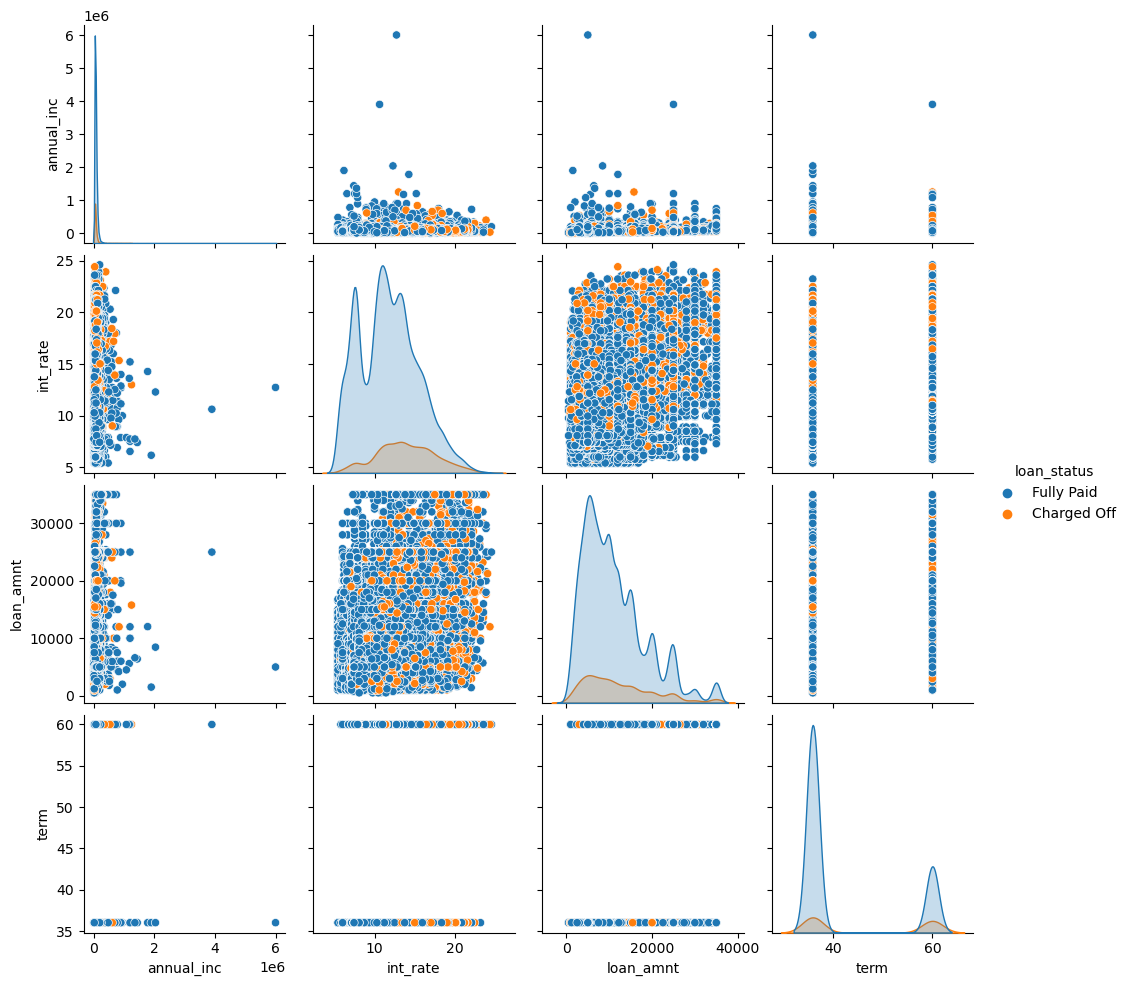

In [ ]:
#Identificación gráfica
sb.pairplot(data = datos, hue = 'loan_status', kind = 'scatter')
plt.show()

In [ ]:
#Ninguna variable numérica es clasificatoria

In [ ]:
datos.describe()

,annual_inc,int_rate,loan_amnt,term
count,3.870500e+04,38705.000000,38705.000000,38705.000000
mean,6.961750e+04,12.059525,11303.916161,42.461801
std,6.422378e+04,3.719517,7470.319733,10.645716
min,4.000000e+03,5.420000,500.000000,36.000000
25%,4.149600e+04,9.320000,5500.000000,36.000000
50%,6.000000e+04,11.860000,10000.000000,36.000000
75%,8.320000e+04,14.590000,15000.000000,60.000000
max,6.000000e+06,24.590000,35000.000000,60.000000


In [ ]:
datos.describe(include = 'object')

,loan_status,verification_status,emp_length,home_ownership,purpose,grade
count,38705,38705,38705,38705,38705,38705
unique,2,3,11,4,14,7
top,Fully Paid,Not Verified,10+ years,RENT,debt_consolidation,B
freq,33265,16499,8899,18507,18275,11697


In [ ]:
#TRANSFORMACIÓN DE VARIABLES
numCols = datos.select_dtypes(include = ['float64', 'int64', 'int32']).columns.to_list()
matCols = datos[['verification_status', 'home_ownership', 'grade']].columns.to_list()
ordCols = datos[['loan_status', 'emp_length', 'purpose']].columns.to_list()

In [ ]:
numTransformer = Pipeline(steps = [('scaler', MinMaxScaler())])
matTransformer = Pipeline(steps = [('onehot', OneHotEncoder(handle_unknown = 'ignore'))])
ordTransformer = Pipeline(steps = [('ordinal', OrdinalEncoder(handle_unknown = 'error'))])

In [ ]:
preprocesador = ColumnTransformer(transformers = [
    ('num', numTransformer, numCols),
    ('mat', matTransformer, matCols),
    ('ord', ordTransformer, ordCols)
], remainder = 'passthrough')

set_config(display = 'diagram')
preprocesador

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['annual_inc', 'int_rate', 'loan_amnt',
                                  'term']),
                                ('mat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['verification_status', 'home_ownership',
                                  'grade']),
                                ('ord',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder())]),
                                 ['loan_status', 'emp_length', 'purpose'])])

In [ ]:
datosPre = preprocesador.fit_transform(datos)
datosPre

array([[3.33555704e-03, 2.72822118e-01, 1.30434783e-01, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [4.33622415e-03, 5.13823683e-01, 5.79710145e-02, ...,
        0.00000000e+00, 1.00000000e+01, 0.00000000e+00],
       [1.37625083e-03, 5.49817423e-01, 5.50724638e-02, ...,
        1.00000000e+00, 1.00000000e+00, 1.10000000e+01],
       ...,
       [1.60106738e-02, 1.38236828e-01, 1.30434783e-01, ...,
        1.00000000e+00, 1.00000000e+01, 2.00000000e+00],
       [3.26884590e-02, 1.04851330e-01, 1.30434783e-01, ...,
        1.00000000e+00, 1.00000000e+01, 9.00000000e+00],
       [3.00200133e-03, 4.34533125e-01, 2.02898551e-01, ...,
        1.00000000e+00, 1.00000000e+01, 2.00000000e+00]])

In [ ]:
codCat = preprocesador.named_transformers_['mat']['onehot'].get_feature_names(matCols)
labels = np.concatenate([numCols, codCat, ordCols])
labels

array(['annual_inc', 'int_rate', 'loan_amnt', 'term',
       'verification_status_Not Verified',
       'verification_status_Source Verified',
       'verification_status_Verified', 'home_ownership_MORTGAGE',
       'home_ownership_OTHER', 'home_ownership_OWN',
       'home_ownership_RENT', 'grade_A', 'grade_B', 'grade_C', 'grade_D',
       'grade_E', 'grade_F', 'grade_G', 'loan_status', 'emp_length',
       'purpose'], dtype=object)

In [ ]:
datosPro = pd.DataFrame(datosPre, columns = labels)
datosPro.head()

,annual_inc,int_rate,loan_amnt,term,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,...,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,loan_status,emp_length,purpose
0,0.003336,0.272822,0.130435,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
1,0.004336,0.513824,0.057971,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0
2,0.001376,0.549817,0.055072,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,11.0
3,0.007538,0.420970,0.275362,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,9.0
4,0.012675,0.379238,0.072464,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0


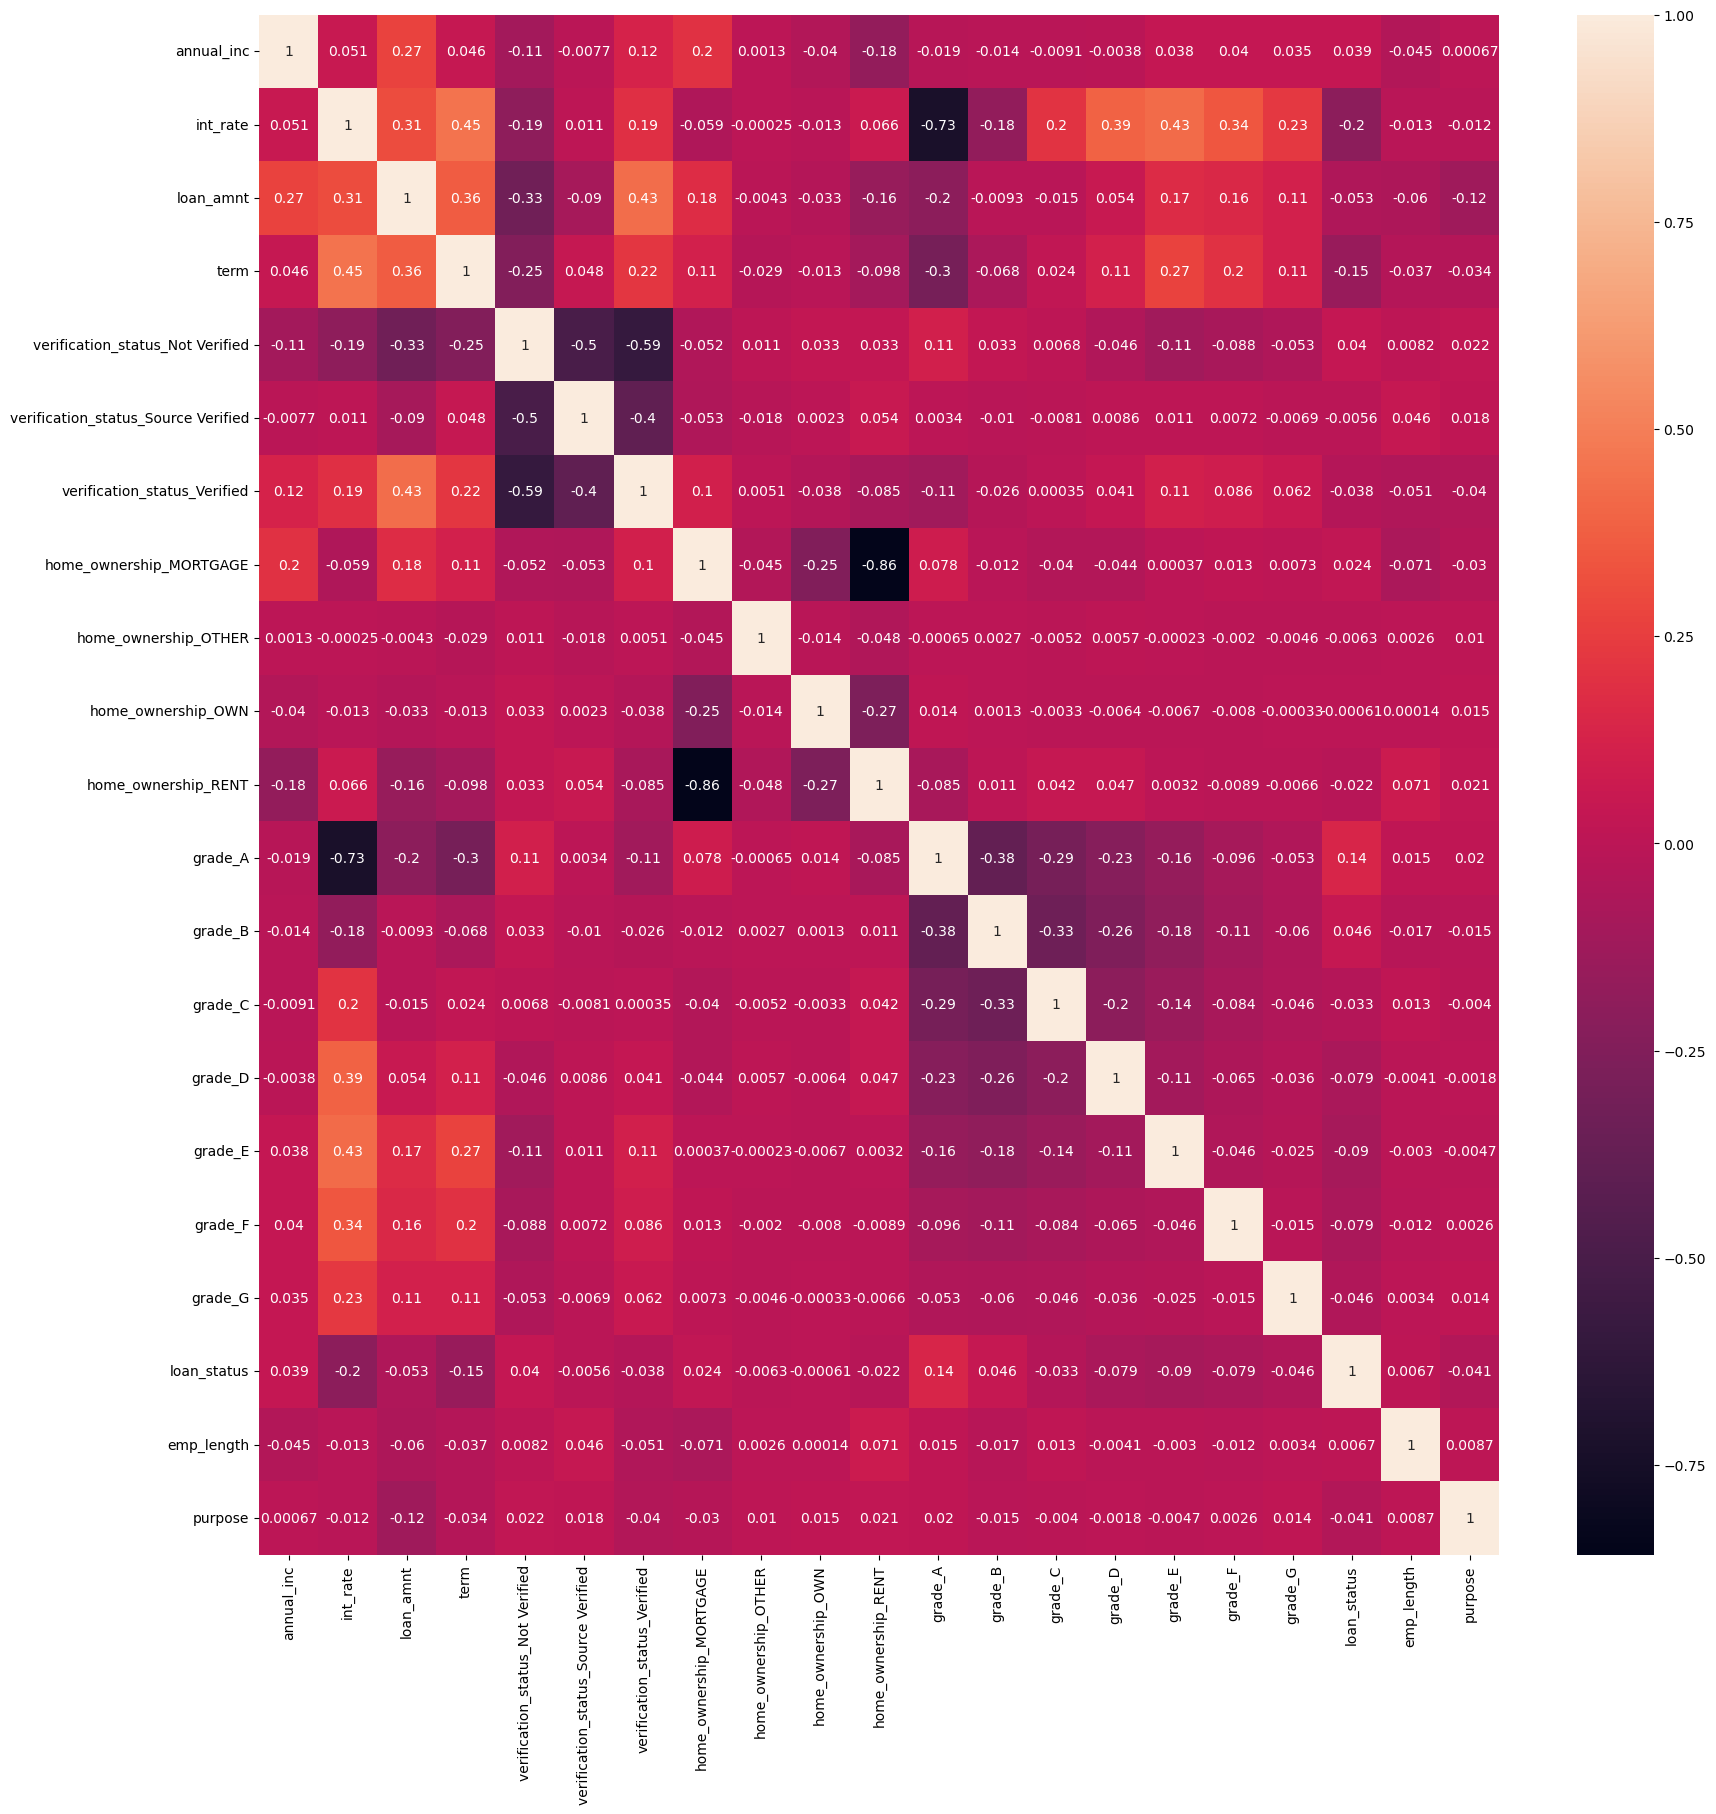

In [ ]:
#Factor de correlación
plt.figure(figsize = (20, 20))
sb.heatmap(datosPro.corr(), annot = True)
plt.show()

In [ ]:
#Punto 2.a
#La variable de mayor correlación con loan_status es int_rate
X1 = datosPro[['int_rate']]
y1 = datosPro['loan_status']

In [ ]:
X1Entrenamiento, X1Prueba, y1Entrenamiento, y1Prueba = train_test_split(X1, y1, train_size = 0.7, random_state = 123)

In [ ]:
#Ajuste del modelo
modelo1 = LogisticRegression(C = 1.0, random_state = 123)
modelo1.fit(X1Entrenamiento, y1Entrenamiento)

LogisticRegression(random_state=123)

El accuracy de entenamiento es 0.8587088915956151


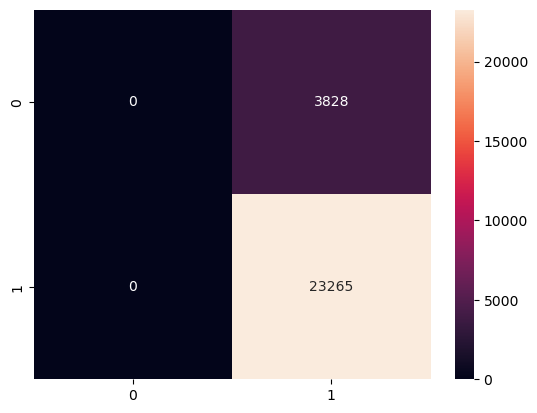

In [ ]:
#Ajuste de entrenamiento
predModelo1Entrenamiento = modelo1.predict(X1Entrenamiento)
accuracyModelo1Entrenamiento = accuracy_score(y1Entrenamiento, predModelo1Entrenamiento)
matrizModelo1Entrenamiento = confusion_matrix(y1Entrenamiento, predModelo1Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo1Entrenamiento}')
sb.heatmap(matrizModelo1Entrenamiento, annot = True, fmt = 'd')
plt.show()

El accuracy de prueba es 0.861178091629349


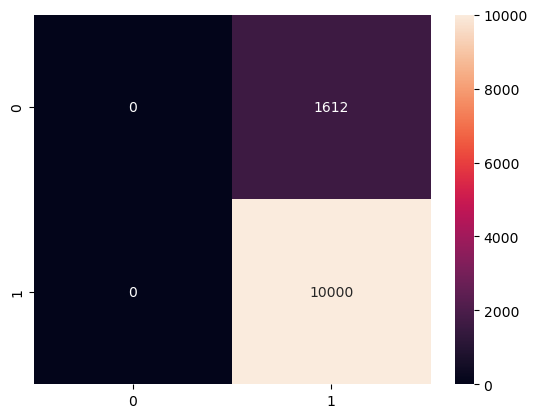

In [ ]:
#Ajuste de prueba
predModelo1Prueba = modelo1.predict(X1Prueba)
accuracyModelo1Prueba = accuracy_score(y1Prueba, predModelo1Prueba)
matrizModelo1Prueba = confusion_matrix(y1Prueba, predModelo1Prueba)
print(f'El accuracy de prueba es {accuracyModelo1Prueba}')
sb.heatmap(matrizModelo1Prueba, annot = True, fmt = 'd')
plt.show()

In [ ]:
#Punto 2.b
X2 = datosPro.drop('loan_status', axis = 1)
y2 = datosPro['loan_status']

In [ ]:
X2Entrenamiento, X2Prueba, y2Entrenamiento, y2Prueba = train_test_split(X2, y2, train_size = 0.7, random_state = 123)

In [ ]:
#Ajuste del modelo
modelo2 = LogisticRegression(C = 1.0, random_state = 123)
modelo2.fit(X2Entrenamiento, y2Entrenamiento)

LogisticRegression(random_state=123)

El accuracy de entenamiento es 0.8587458014985421


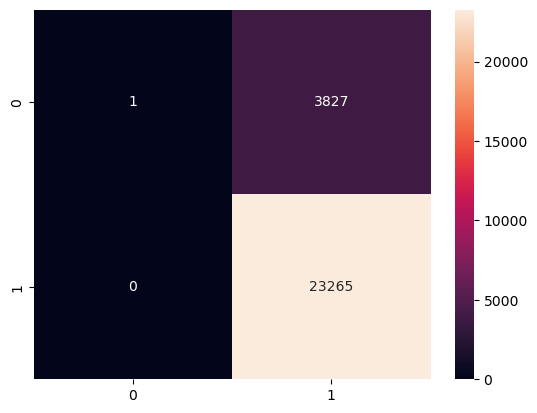

In [ ]:
#Ajuste de entrenamiento
predModelo2Entrenamiento = modelo2.predict(X2Entrenamiento)
accuracyModelo2Entrenamiento = accuracy_score(y2Entrenamiento, predModelo2Entrenamiento)
matrizModelo2Entrenamiento = confusion_matrix(y2Entrenamiento, predModelo2Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo2Entrenamiento}')
sb.heatmap(matrizModelo2Entrenamiento, annot = True, fmt = 'd')
plt.show()

El accuracy de prueba es 0.861178091629349


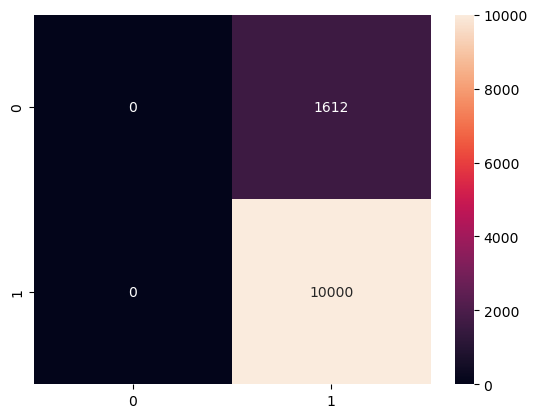

In [ ]:
#Ajuste de prueba
predModelo2Prueba = modelo2.predict(X2Prueba)
accuracyModelo2Prueba = accuracy_score(y2Prueba, predModelo2Prueba)
matrizModelo2Prueba = confusion_matrix(y2Prueba, predModelo2Prueba)
print(f'El accuracy de prueba es {accuracyModelo2Prueba}')
sb.heatmap(matrizModelo2Prueba, annot = True, fmt = 'd')
plt.show()

In [ ]:
#Punto 2.c
#Variables elegidas: cb_person_default_on_file, person_home_ownership, loan_percent_income, loan_status, loan_int_rate, loan_amnt
X3 = datosPro[['grade_A', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G',
              'term', 'int_rate']]
y3 = datosPro['loan_status']

In [ ]:
X3Entrenamiento, X3Prueba, y3Entrenamiento, y3Prueba = train_test_split(X2, y2, train_size = 0.7, random_state = 123)

In [ ]:
#Ajuste del modelo
modelo3 = SVC(random_state = 123)
modelo3.fit(X3Entrenamiento, y3Entrenamiento)

SVC(random_state=123)

El accuracy de entenamiento es 0.8587088915956151


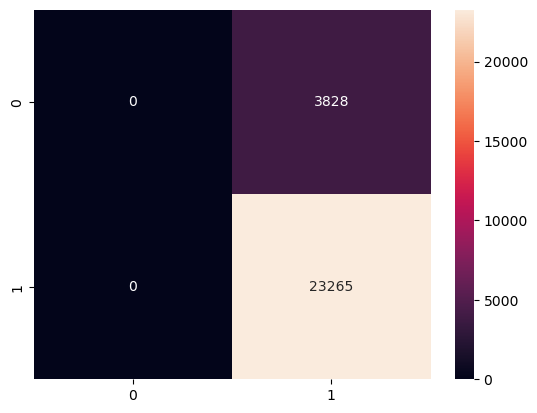

In [ ]:
#Ajuste de entrenamiento
predModelo3Entrenamiento = modelo3.predict(X3Entrenamiento)
accuracyModelo3Entrenamiento = accuracy_score(y3Entrenamiento, predModelo3Entrenamiento)
matrizModelo3Entrenamiento = confusion_matrix(y3Entrenamiento, predModelo3Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo3Entrenamiento}')
sb.heatmap(matrizModelo3Entrenamiento, annot = True, fmt = 'd')
plt.show()

El accuracy de prueba es 0.861178091629349


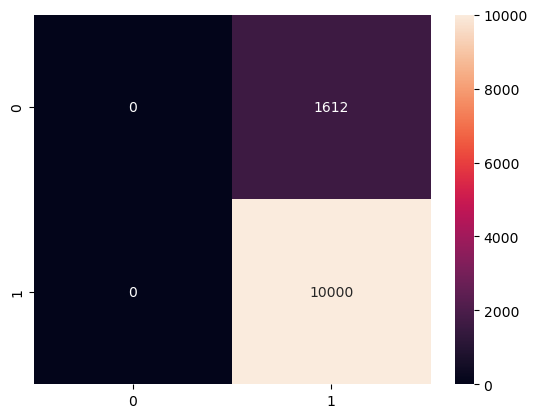

In [ ]:
#Ajuste de prueba
predModelo3Prueba = modelo3.predict(X3Prueba)
accuracyModelo3Prueba = accuracy_score(y3Prueba, predModelo3Prueba)
matrizModelo3Prueba = confusion_matrix(y3Prueba, predModelo3Prueba)
print(f'El accuracy de prueba es {accuracyModelo3Prueba}')
sb.heatmap(matrizModelo3Prueba, annot = True, fmt = 'd')
plt.show()

In [ ]:
#Punto 2.d
modelo4 = MLPClassifier(hidden_layer_sizes = (10, 20), random_state = 123)
modelo4.fit(X3Entrenamiento, y3Entrenamiento)

MLPClassifier(hidden_layer_sizes=(10, 20), random_state=123)

El accuracy de entenamiento es 0.8587088915956151


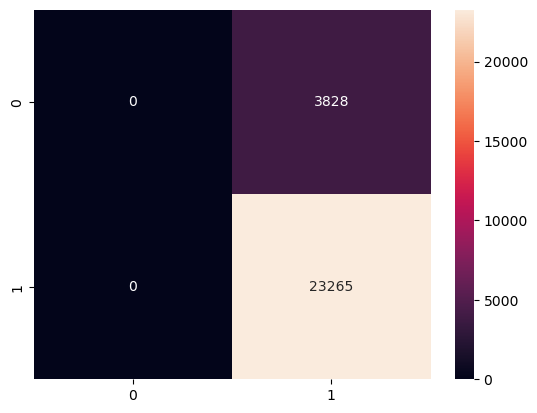

In [ ]:
#Ajuste de entrenamiento
predModelo4Entrenamiento = modelo4.predict(X3Entrenamiento)
accuracyModelo4Entrenamiento = accuracy_score(y3Entrenamiento, predModelo3Entrenamiento)
matrizModelo4Entrenamiento = confusion_matrix(y3Entrenamiento, predModelo3Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo4Entrenamiento}')
sb.heatmap(matrizModelo4Entrenamiento, annot = True, fmt = 'd')
plt.show()

El accuracy de prueba es 0.861178091629349


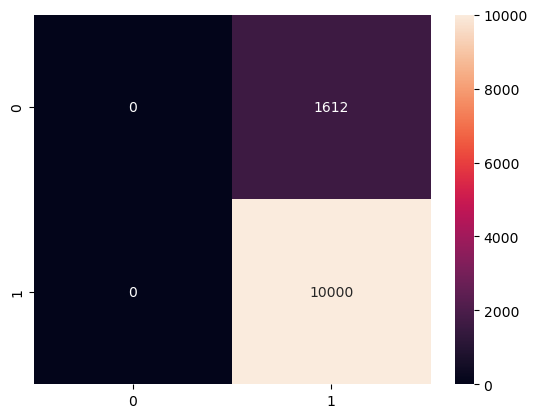

In [ ]:
#Ajuste de prueba
predModelo4Prueba = modelo3.predict(X3Prueba)
accuracyModelo4Prueba = accuracy_score(y3Prueba, predModelo3Prueba)
matrizModelo4Prueba = confusion_matrix(y3Prueba, predModelo3Prueba)
print(f'El accuracy de prueba es {accuracyModelo4Prueba}')
sb.heatmap(matrizModelo4Prueba, annot = True, fmt = 'd')
plt.show()

In [ ]:
#Punto 2.e
#Los datos pueden ajustarse a una Máquina de Soporte Vectorial o a una Red Neuronal Artificial, pero si se analiza la
#matriz de confusión el "mejor" modelo es la regresión logística multivariada
#El problema tiene desbalanceo de la salida, la mejor manera de abordarlo es balanceando la y

In [ ]:
#Problema con y balanceada

In [ ]:
datosPro1 = datosPro[datosPro['loan_status'] == 1]
datosPro1.shape

(33265, 21)

In [ ]:
datosPro0 = datosPro[datosPro['loan_status'] == 0]
datosPro0.shape

(5440, 21)

In [ ]:
datosPro0 = datosPro0.sample(datosPro1.shape[0], replace = True)
datosPro0.shape

(33265, 21)

In [ ]:
datosPro = pd.concat([datosPro0, datosPro1])
datosPro.shape

(66530, 21)

In [ ]:
datosPro.head()

,annual_inc,int_rate,loan_amnt,term,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,...,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,loan_status,emp_length,purpose
958,0.004670,0.461659,0.130435,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
4692,0.009673,0.689619,0.385507,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,11.0
4737,0.014343,0.669275,0.260870,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,11.0
37415,0.008506,0.305686,0.130435,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,13.0
35693,0.013508,0.453312,0.634783,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,9.0


In [ ]:
datosPro.tail()

,annual_inc,int_rate,loan_amnt,term,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,...,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,loan_status,emp_length,purpose
38700,0.017678,0.138237,0.057971,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,4.0
38701,0.002335,0.253521,0.231884,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0
38702,0.016011,0.138237,0.130435,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,2.0
38703,0.032688,0.104851,0.130435,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,9.0
38704,0.003002,0.434533,0.202899,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,10.0,2.0


In [ ]:
#Punto 2.a y balanceada
#La variable de mayor correlación con loan_status es int_rate
X1 = datosPro[['int_rate']]
y1 = datosPro['loan_status']

In [ ]:
X1Entrenamiento, X1Prueba, y1Entrenamiento, y1Prueba = train_test_split(X1, y1, train_size = 0.7, random_state = 123)

In [ ]:
#Ajuste del modelo
modelo1 = LogisticRegression(C = 1.0, random_state = 123)
modelo1.fit(X1Entrenamiento, y1Entrenamiento)

LogisticRegression(random_state=123)

El accuracy de entenamiento es 0.6093491657898692


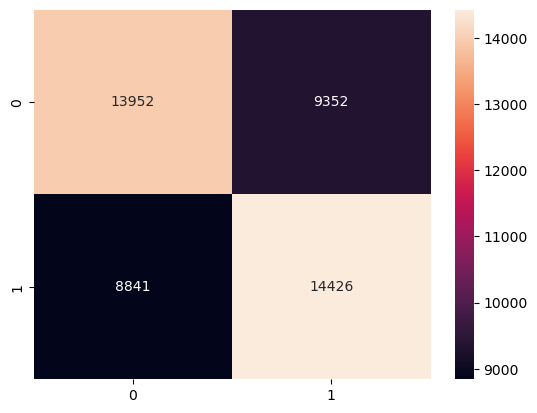

In [ ]:
#Ajuste de entrenamiento
predModelo1Entrenamiento = modelo1.predict(X1Entrenamiento)
accuracyModelo1Entrenamiento = accuracy_score(y1Entrenamiento, predModelo1Entrenamiento)
matrizModelo1Entrenamiento = confusion_matrix(y1Entrenamiento, predModelo1Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo1Entrenamiento}')
sb.heatmap(matrizModelo1Entrenamiento, annot = True, fmt = 'd')
plt.show()

El accuracy de prueba es 0.6091988576581993


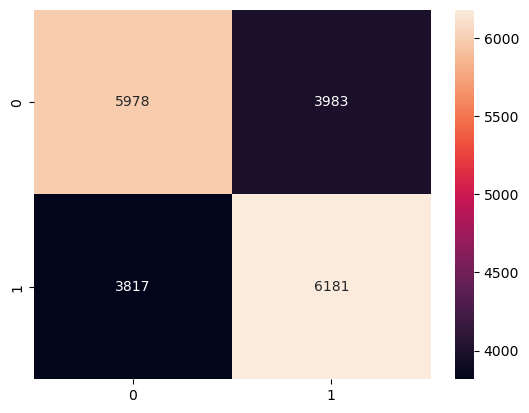

In [ ]:
#Ajuste de prueba
predModelo1Prueba = modelo1.predict(X1Prueba)
accuracyModelo1Prueba = accuracy_score(y1Prueba, predModelo1Prueba)
matrizModelo1Prueba = confusion_matrix(y1Prueba, predModelo1Prueba)
print(f'El accuracy de prueba es {accuracyModelo1Prueba}')
sb.heatmap(matrizModelo1Prueba, annot = True, fmt = 'd')
plt.show()

In [ ]:
#Punto 2.b - y balanceada
X2 = datosPro.drop('loan_status', axis = 1)
y2 = datosPro['loan_status']

In [ ]:
X2Entrenamiento, X2Prueba, y2Entrenamiento, y2Prueba = train_test_split(X2, y2, train_size = 0.7, random_state = 123)

In [ ]:
#Ajuste del modelo
modelo2 = LogisticRegression(C = 1.0, random_state = 123)
modelo2.fit(X2Entrenamiento, y2Entrenamiento)

LogisticRegression(random_state=123)

El accuracy de entenamiento es 0.6275364497219299


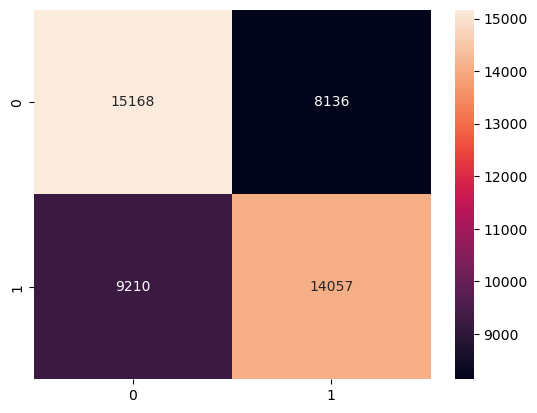

In [ ]:
#Ajuste de entrenamiento
predModelo2Entrenamiento = modelo2.predict(X2Entrenamiento)
accuracyModelo2Entrenamiento = accuracy_score(y2Entrenamiento, predModelo2Entrenamiento)
matrizModelo2Entrenamiento = confusion_matrix(y2Entrenamiento, predModelo2Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo2Entrenamiento}')
sb.heatmap(matrizModelo2Entrenamiento, annot = True, fmt = 'd')
plt.show()

El accuracy de prueba es 0.6290395310386292


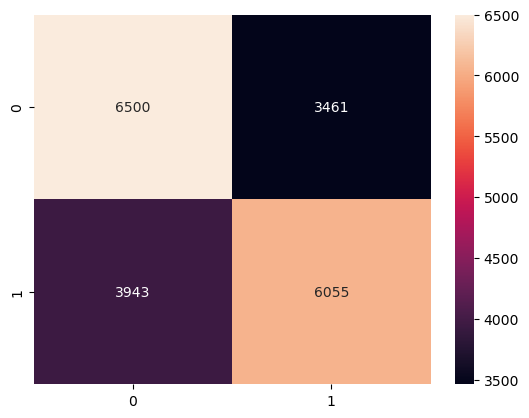

In [ ]:
#Ajuste de prueba
predModelo2Prueba = modelo2.predict(X2Prueba)
accuracyModelo2Prueba = accuracy_score(y2Prueba, predModelo2Prueba)
matrizModelo2Prueba = confusion_matrix(y2Prueba, predModelo2Prueba)
print(f'El accuracy de prueba es {accuracyModelo2Prueba}')
sb.heatmap(matrizModelo2Prueba, annot = True, fmt = 'd')
plt.show()

In [ ]:
#Punto 2.c - y balanceada
#Variables elegidas: cb_person_default_on_file, person_home_ownership, loan_percent_income, loan_status, loan_int_rate, loan_amnt
X3 = datosPro[['grade_A', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G',
              'term', 'int_rate']]
y3 = datosPro['loan_status']

In [ ]:
X3Entrenamiento, X3Prueba, y3Entrenamiento, y3Prueba = train_test_split(X2, y2, train_size = 0.7, random_state = 123)

In [ ]:
#Ajuste del modelo
modelo3 = SVC(random_state = 123)
modelo3.fit(X3Entrenamiento, y3Entrenamiento)

SVC(random_state=123)

El accuracy de entenamiento es 0.6192265572996071


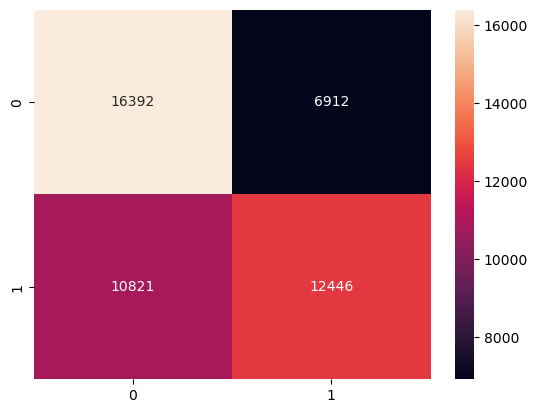

In [ ]:
#Ajuste de entrenamiento
predModelo3Entrenamiento = modelo3.predict(X3Entrenamiento)
accuracyModelo3Entrenamiento = accuracy_score(y3Entrenamiento, predModelo3Entrenamiento)
matrizModelo3Entrenamiento = confusion_matrix(y3Entrenamiento, predModelo3Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo3Entrenamiento}')
sb.heatmap(matrizModelo3Entrenamiento, annot = True, fmt = 'd')
plt.show()

El accuracy de prueba es 0.6196202214539807


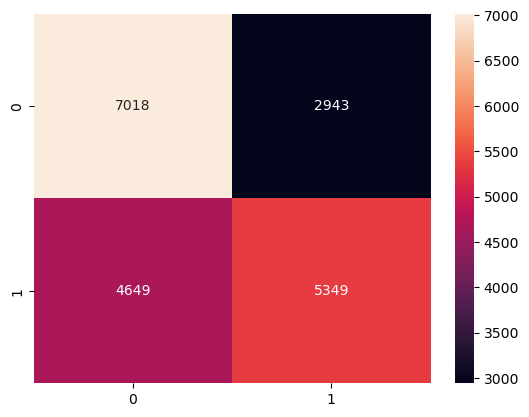

In [ ]:
#Ajuste de prueba
predModelo3Prueba = modelo3.predict(X3Prueba)
accuracyModelo3Prueba = accuracy_score(y3Prueba, predModelo3Prueba)
matrizModelo3Prueba = confusion_matrix(y3Prueba, predModelo3Prueba)
print(f'El accuracy de prueba es {accuracyModelo3Prueba}')
sb.heatmap(matrizModelo3Prueba, annot = True, fmt = 'd')
plt.show()

In [ ]:
#Punto 2.d - y balanceada
modelo4 = MLPClassifier(hidden_layer_sizes = (10, 20), random_state = 123)
modelo4.fit(X3Entrenamiento, y3Entrenamiento)

MLPClassifier(hidden_layer_sizes=(10, 20), random_state=123)

El accuracy de entenamiento es 0.6192265572996071


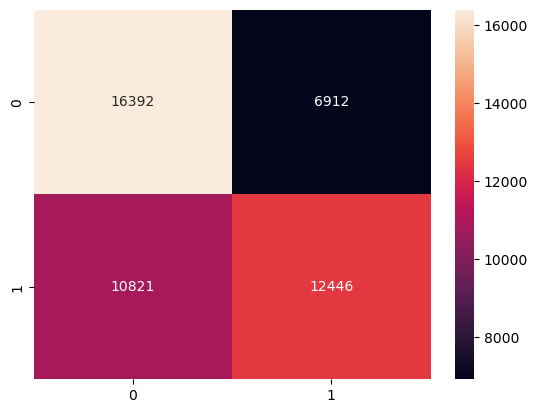

In [ ]:
#Ajuste de entrenamiento
predModelo4Entrenamiento = modelo4.predict(X3Entrenamiento)
accuracyModelo4Entrenamiento = accuracy_score(y3Entrenamiento, predModelo3Entrenamiento)
matrizModelo4Entrenamiento = confusion_matrix(y3Entrenamiento, predModelo3Entrenamiento)
print(f'El accuracy de entenamiento es {accuracyModelo4Entrenamiento}')
sb.heatmap(matrizModelo4Entrenamiento, annot = True, fmt = 'd')
plt.show()

El accuracy de prueba es 0.6196202214539807


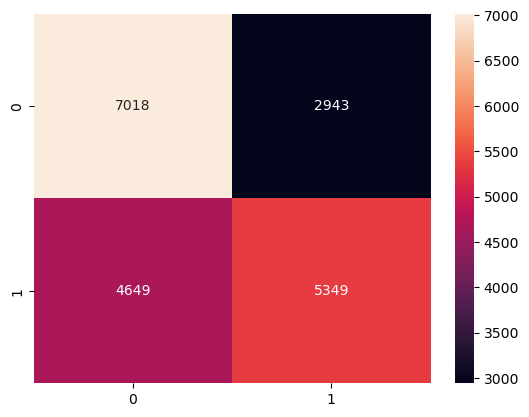

In [ ]:
#Ajuste de prueba
predModelo4Prueba = modelo3.predict(X3Prueba)
accuracyModelo4Prueba = accuracy_score(y3Prueba, predModelo3Prueba)
matrizModelo4Prueba = confusion_matrix(y3Prueba, predModelo3Prueba)
print(f'El accuracy de prueba es {accuracyModelo4Prueba}')
sb.heatmap(matrizModelo4Prueba, annot = True, fmt = 'd')
plt.show()

In [ ]:
#Punto 2.e - y balanceada
#Los datos pueden ajustarse a una Máquina de Soporte Vectorial o a una Red Neuronal Artificial

# PUNTO 3
3.	Rechazar a cualquiera que no tenga una fuente de ingresos verificada es una política relevante que las plataformas de préstamo P2P pueden poner en marcha para ayudar a reducir la tasa de préstamos que caen en impago. Es natural sospechar que, si no se puede verificar la fuente de ingresos de una persona, ésta podría no pagar el préstamo. Sin embargo, desde el punto de vista del prestatario, el proceso de verificación puede ser engorroso y llevar mucho tiempo, por lo que es posible que se cambie a otra plataforma debido a este inconveniente. Como analista de la empresa de préstamos P2P del punto dos, debe dar respuesta a la siguiente pregunta: "¿Debe la empresa verificar la fuente de ingresos de un solicitante de préstamo online antes de aprobar su préstamo? ". Desarrolle los modelos necesarios para responder esta pregunta con suficiente evidencia.

In [ ]:
#En la correlación tanto la variable ingresos como la variable de chequeo aportan poca información a la resolución del
#problema